[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/notebooks/EN/chapter2_lecture_notebook.ipynb)

# Advanced Time Series Analysis and Forecasting — Chapter 2: Structural breaks and nonlinear models

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Breaks at known and unknown dates: the Chow test, sup-, exp- and ave-Wald (Andrews 1993; Andrews and Ploberger 1994), the Great Moderation test of McConnell and Perez-Quiros (2000).
- Multiple breaks (Bai and Perron 1998, 2003): dynamic programming, tests, BIC and LWZ, intervals for the dates; the US real interest rate and Romanian inflation.
- Monitoring (Chu, Stinchcombe and White 1996), variance breaks (ICSS, kappa-2), unit roots with breaks, the choice of the estimation window.
- Threshold and smooth-transition models: Tong and Lim (1980), Hansen (1997), van Dijk, Teräsvirta and Franses (2002), Taylor, Peel and Sarno (2001); nonlinearity tests and nonlinear forecasts.
- The simulations use fewer replications than the slides, so some numbers differ slightly.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_2'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/ATS - Modelarea avansata a seriilor de timp/repo/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Definitions and helpers used in the whole notebook

- Data: `bp_real_rate`, `us_real_rate`, `ro_hicp`, `us_gdp_growth`, `unemp_men`, `real_usd_gbp`, `lynx`.
- Breaks: `andrews_tests`, `segment_ssr`, `dp_breaks`, `bp_analysis`, `bp_fit`, `bai_ci_quantiles`, `icss`, `csw_boundary`.
- Nonlinear models: `tar_estimate`, `hansen_test`, `lm3_test`, `star_fit`, `estar_fit`, `estar_girf_history`, `keenan_test`, `tsay_test`, `bds_test`.

In [5]:
import io
import zipfile
import urllib.error
import statsmodels.api as sm
HERE = "."
SEED = 2026
TRIM = 0.15
HICP_RO = ('prc_hicp_minr', 'M.RCH_A.TOTAL.RO')
GDP_RO = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
BP_URL = 'http://qed.econ.queensu.ca/jae/2003-v18.1/bai-perron/bp-data.zip'
MPQ_SAMPLE = ('1953-04-01', '1999-04-01')
HANSEN_SAMPLE = ('1959-01-01', '1996-07-01')
VDTF_SAMPLE = ('1968-06-01', '1999-12-01', '1989-12-01')
TPS_SAMPLE = ('1973-01-01', '1996-12-01')
UK_CPI_ONS = 'https://www.ons.gov.uk/generator?format=csv&uri=/economy/inflationandpriceindices/timeseries/d7bt/mm23'
MON_HIST = ('2015-01-01', '2019-12-01')
LYNX_SPEC = (7, 2, 2)
LWZ_C0, LWZ_D0 = 0.299, 0.1
A2_5 = 7.78
_FILES = {}
_NULL = {}
# Bai-Perron critical values (simulated once with bp_critical(T=1000, reps=1000); see generate_all_charts.py)
_BPCV = {'cv': {"T": 1000, "reps": 1000, "h": 150, "0.10": {"supF": [7.322371381025062, 6.344773604508686, 5.254470804906281, 4.405483410260758, 3.323999049482492], "UDmax": 7.688299359394575, "WDmax": 8.654388747387188, "seq": [8.727514878572347, 9.548329026081907, 10.527401722365736, 11.372495761411466]}, "0.05": {"supF": [8.73565483415872, 7.269454777472157, 6.052808536671888, 4.905247793840771, 3.8113917106752906], "UDmax": 8.865985232666754, "WDmax": 10.135588137265033, "seq": [10.537088133015938, 11.559607468696287, 11.956268366315074, 13.285584261596563]}, "0.01": {"supF": [13.302833718226006, 8.59275828135307, 7.487615986807845, 6.114998121437082, 4.641838995948307], "UDmax": 13.303865602045159, "WDmax": 15.085966620369474, "seq": [14.466784827343213, 15.044271571989226, 15.151445171680374, 15.21933654088081]}}}


def get_bytes(url):
    """Download a public file once per session (no key); optional local cache folder ATS_CACHE."""
    import hashlib
    import time
    if url in _FILES:
        return _FILES[url]
    cache = os.environ.get('ATS_CACHE')
    path = os.path.join(cache, hashlib.md5(url.encode()).hexdigest()) if cache else None
    if path and os.path.exists(path):
        _FILES[url] = open(path, 'rb').read()
        return _FILES[url]
    for attempt in range(5):
        try:
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0 (ATS course)'})
            _FILES[url] = urllib.request.urlopen(req, timeout=180).read()
            break
        except urllib.error.URLError:
            if attempt == 4:
                raise
            time.sleep(5 * (attempt + 1))
    if path:
        os.makedirs(cache, exist_ok=True)
        open(path, 'wb').write(_FILES[url])
    return _FILES[url]


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def bp_real_rate():
    """US ex-post real interest rate, quarterly 1961Q1-1986Q3 (Garcia and Perron 1996), as used by Bai and Perron (2003)."""
    z = zipfile.ZipFile(io.BytesIO(get_bytes(BP_URL)))
    v = np.array([float(x) for x in z.read('real.dat').decode().split()])
    return pd.Series(v, index=pd.period_range('1961Q1', periods=len(v), freq='Q').to_timestamp(), name='real rate')


def us_real_rate():
    """Ex-post real rate rebuilt from FRED, 1961Q1 to the last quarter: the 3-month T-bill rate in the last month of quarter
    t (TB3MS) minus the annualised CPI inflation of quarter t + 1 (CPIAUCNS, last month of each quarter), in %. Over
    1961Q1-1986Q3 this construction has a correlation of 0.99 with the Bai-Perron series."""
    tb = read_fred('TB3MS').resample('QS').last()
    c = read_fred('CPIAUCNS')
    n = c.resample('QS').count()
    p = c.resample('QS').last()[n == 3]
    infl = 400 * np.log(p).diff()
    r = (tb - infl.shift(-1)).dropna().loc['1961-01-01':]
    return r.rename('real rate')


def ro_hicp(start='2000-01-01'):
    """Romanian HICP inflation, annual rate of change, monthly, % (Eurostat)."""
    return read_eurostat(*HICP_RO).loc[start:].rename('HICP RO')


def us_gdp_growth():
    """US real GDP growth, quarterly, 100 x log difference (FRED GDPC1)."""
    return (100 * np.log(read_fred('GDPC1')).diff()).dropna().rename('GDP growth')


def unemp_men(sa=True):
    """US unemployment rate of men aged 20 and over, monthly, %, computed as the ratio of the unemployment level to the
    civilian labour force of this group (BLS series via FRED: LNS13000025 / LNS11000025 seasonally adjusted,
    LNU03000025 / LNU01000025 not adjusted), the construction of Hansen (1997) and van Dijk et al. (2002)."""
    u, lf = ('LNS13000025', 'LNS11000025') if sa else ('LNU03000025', 'LNU01000025')
    return (100 * read_fred(u) / read_fred(lf)).dropna().rename('unemployment men 20+')


def uk_cpi():
    """UK CPI, all items, 2015 = 100: OECD Main Economic Indicators (FRED GBRCPIALLMINMEI) to 1987, then ONS series D7BT
    (CPI index 00, monthly from 1988), spliced at January 1988."""
    mei = read_fred('GBRCPIALLMINMEI')
    t = pd.read_csv(io.BytesIO(get_bytes(UK_CPI_ONS)), header=None, names=['p', 'v'])
    t = t[t['p'].astype(str).str.match(r'^\d{4} [A-Z]{3}$')]
    ons = pd.Series(pd.to_numeric(t['v']).values, index=pd.to_datetime(t['p'], format='%Y %b')).sort_index()
    k = ons.loc['1988-01-01'] / mei.loc['1988-01-01']
    return pd.concat([k * mei.loc[:'1987-12-01'], ons.loc['1988-01-01':]]).rename('UK CPI')


def real_usd_gbp(start=TPS_SAMPLE[0], end=None):
    """Log real dollar-sterling rate q = s + p* - p (s: dollars per pound at the end of the month, FRED DEXUSUK; p: US CPI
    not seasonally adjusted, CPIAUCNS; p*: UK CPI), normalised so that q(1973M01) = 0, as in Taylor, Peel and Sarno (2001)."""
    s = read_fred('DEXUSUK').dropna().resample('MS').last()
    q = (np.log(s) + np.log(uk_cpi()) - np.log(read_fred('CPIAUCNS'))).dropna().loc[start:end]
    return (q - q.iloc[0]).rename('q')


def ro_reer():
    """Romania, real effective exchange rate (broad, CPI-based), monthly, BIS via FRED RBROBIS; log, 2020 = 0."""
    r = np.log(read_fred('RBROBIS').dropna())
    return (r - r.loc['2020'].mean()).rename('REER RO')


def lynx():
    """Canadian lynx trappings, 1821-1934 (Elton and Nicholson 1942), the R data set read by statsmodels; log10."""
    import statsmodels.api as sm
    d = sm.datasets.get_rdataset('lynx').data
    return pd.Series(np.log10(d['value'].values), index=d['time'].astype(int).values, name='log10 lynx')


def qlabel(ts):
    p = pd.Timestamp(ts).to_period('Q')
    return f'{p.year}Q{p.quarter}'


def mlabel(ts):
    return str(pd.Timestamp(ts))[:7]


def ols(y, X):
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    e = y - X @ b
    return b, e, float(e @ e)


def lags(x, p, const=True):
    """Matrix [1, x_{t-1}, ..., x_{t-p}] and the target x_t (numpy arrays, first p rows dropped)."""
    x = np.asarray(x, float)
    T = len(x)
    X = np.column_stack([x[p - j:T - j] for j in range(1, p + 1)]) if p else np.empty((T, 0))
    if const:
        X = np.column_stack([np.ones(T - p), X])
    return x[p:], X


def lrv_qs(u, prewhite=True):
    """Long-run variance of a scalar series: Quadratic Spectral kernel, Andrews (1991) AR(1) plug-in bandwidth, with AR(1)
    prewhitening (Andrews and Monahan 1992), the default of Bai and Perron (2003)."""
    u = np.asarray(u, float) - np.mean(u)
    T = len(u)
    rho = 0.0
    if prewhite and T > 3:
        rho = float(u[1:] @ u[:-1] / (u[:-1] @ u[:-1]))
        rho = max(min(rho, 0.97), -0.97)
        u = u[1:] - rho * u[:-1]
        T = len(u)
    a = float(u[1:] @ u[:-1] / (u[:-1] @ u[:-1])) if T > 3 else 0.0
    a = max(min(a, 0.97), -0.97)
    alpha2 = 4 * a ** 2 / (1 - a) ** 4
    bw = 1.3221 * (alpha2 * T) ** 0.2 if alpha2 > 0 else 0.0
    v = u @ u / T
    if bw > 0:
        for j in range(1, T):
            x = 6 * np.pi * (j / bw) / 5
            w = 25 / (12 * np.pi ** 2 * (j / bw) ** 2) * (np.sin(x) / x - np.cos(x))
            g = u[j:] @ u[:-j] / T
            v += 2 * w * g
            if j > 20 * bw + 50:
                break
    return float(v / (1 - rho) ** 2)


def nw_lrv(u, L=None):
    """Bartlett (Newey-West) long-run variance with the lag 4 (T/100)^(2/9) if L is None."""
    u = np.asarray(u, float) - np.mean(u)
    T = len(u)
    L = int(np.floor(4 * (T / 100) ** (2 / 9))) if L is None else L
    v = u @ u / T
    for k in range(1, L + 1):
        v += 2 * (1 - k / (L + 1)) * (u[k:] @ u[:-k]) / T
    return float(v)


def recursive_residuals(y, X):
    """Standardised recursive residuals w_t = (y_t - x_t' b_{t-1}) / sqrt(1 + x_t'(X_{t-1}'X_{t-1})^{-1} x_t), t = k+1..T
    (Brown, Durbin and Evans 1975)."""
    T, k = X.shape
    w = np.full(T, np.nan)
    for t in range(k, T):
        Xt, yt = X[:t], y[:t]
        A = np.linalg.pinv(Xt.T @ Xt)
        b = A @ Xt.T @ yt
        w[t] = (y[t] - X[t] @ b) / np.sqrt(1 + X[t] @ A @ X[t])
    return w


def dm_hln(d, h=1):
    """Diebold-Mariano with the Harvey-Leybourne-Newbold correction for a loss differential d (h - 1 rectangular lags),
    Student t(T - 1) p-value (two-sided)."""
    d = np.asarray(d, float)
    d = d[~np.isnan(d)]
    T = len(d)
    v = np.var(d)
    x = d - d.mean()
    for k in range(1, h):
        v += 2 * (x[k:] @ x[:-k]) / T
    dm = d.mean() / np.sqrt(v / T)
    hln = dm * np.sqrt((T + 1 - 2 * h + h * (h - 1) / T) / T)
    return {'T': T, 'dbar': float(d.mean()), 'hln': float(hln), 'p': float(2 * stats.t.sf(abs(hln), T - 1))}


def break_wald_seq(y, X, trim=TRIM, robust='hc', idx=None):
    """Wald statistics for a break in the coefficients idx (default: all) at every date in the trimmed range:
    y = X b + (X_idx 1{t > k}) d + e, robust variance (hc: White; hac: QS prewhitened, scalar case only; none)."""
    y, X = np.asarray(y, float), np.asarray(X, float)
    T, p = X.shape
    idx = list(range(p)) if idx is None else idx
    ks = np.arange(int(np.floor(trim * T)), int(np.ceil((1 - trim) * T)) + 1)
    W = np.full(len(ks), np.nan)
    for i, k in enumerate(ks):
        D = X[:, idx] * (np.arange(T) >= k)[:, None]
        Z = np.column_stack([X, D])
        b, e, ssr = ols(y, Z)
        A = np.linalg.pinv(Z.T @ Z)
        if robust == 'hc':
            V = A @ (Z.T * e ** 2) @ Z @ A
        elif robust == 'hac':
            S = np.zeros((Z.shape[1], Z.shape[1]))
            g = Z * e[:, None]
            L = int(np.floor(4 * (T / 100) ** (2 / 9)))
            S = g.T @ g
            for l in range(1, L + 1):
                G = g[l:].T @ g[:-l]
                S += (1 - l / (L + 1)) * (G + G.T)
            V = A @ S @ A
        else:
            V = A * ssr / (T - Z.shape[1])
        d = b[p:]
        Vd = V[p:, p:]
        W[i] = float(d @ np.linalg.solve(Vd, d))
    return ks, W


def bb_null(p=1, trim=TRIM, reps=20000, grid=2000, seed=SEED):
    """Simulated asymptotic null distribution of the sup, exp and ave Wald statistics (p restrictions): the Wald process
    converges to |B(r) - r B(1)|^2 / (r(1 - r)), B a p-dimensional Brownian motion (Andrews 1993)."""
    rng = np.random.default_rng(seed + p)
    r = np.arange(1, grid + 1) / grid
    keep = (r >= trim) & (r <= 1 - trim)
    sup, exp_, ave = [], [], []
    for _ in range(reps // 1000):
        B = np.cumsum(rng.standard_normal((1000, grid, p)), axis=1) / np.sqrt(grid)
        BB = B - r[None, :, None] * B[:, -1:, :]
        Q = (BB ** 2).sum(axis=2)[:, keep] / (r[keep] * (1 - r[keep]))[None, :]
        sup.append(Q.max(axis=1))
        exp_.append(np.log(np.mean(np.exp(Q / 2), axis=1)))
        ave.append(Q.mean(axis=1))
    return {k: np.concatenate(v) for k, v in (('sup', sup), ('exp', exp_), ('ave', ave))}


def null_dist(p=1, trim=TRIM):
    key = (p, trim)
    if key not in _NULL:
        _NULL[key] = bb_null(p, trim)
    return _NULL[key]


def andrews_tests(y, X, trim=TRIM, robust='hc', idx=None):
    """sup-Wald (Andrews 1993), exp-Wald and ave-Wald (Andrews and Ploberger 1994) with simulated asymptotic p-values."""
    ks, W = break_wald_seq(y, X, trim, robust, idx)
    p = X.shape[1] if idx is None else len(idx)
    nd = null_dist(p, trim)
    out = {'sup': float(W.max()), 'exp': float(np.log(np.mean(np.exp(W / 2)))), 'ave': float(W.mean()),
           'k_hat': int(ks[np.argmax(W)])}
    for s in ('sup', 'exp', 'ave'):
        out[f'p_{s}'] = float(np.mean(nd[s] >= out[s]))
    out['cv_sup'] = float(np.quantile(nd['sup'], 0.95))
    return out, ks, W


def segment_ssr(y, X, h):
    """SSR of the regression of y on X over every segment [i, j] (0-based, inclusive) with at least h observations;
    np.inf otherwise. Uses cumulative sums of X'X and X'y (pure structural change)."""
    y, X = np.asarray(y, float), np.asarray(X, float)
    T, q = X.shape
    Cxx = np.concatenate([np.zeros((1, q, q)), np.cumsum(X[:, :, None] * X[:, None, :], axis=0)])
    Cxy = np.concatenate([np.zeros((1, q)), np.cumsum(X * y[:, None], axis=0)])
    Cyy = np.concatenate([[0.0], np.cumsum(y ** 2)])
    S = np.full((T, T), np.inf)
    if q == 1 and np.allclose(X, 1.0):                  # mean-shift model: closed form
        for i in range(T - h + 1):
            j = np.arange(i + h - 1, T)
            sy = Cxy[j + 1, 0] - Cxy[i, 0]
            S[i, j] = Cyy[j + 1] - Cyy[i] - sy ** 2 / (j - i + 1)
        return S
    for i in range(T - h + 1):
        j = np.arange(i + h - 1, T)
        A = Cxx[j + 1] - Cxx[i]
        c = Cxy[j + 1] - Cxy[i]
        b = np.linalg.solve(A + 1e-12 * np.eye(q)[None], c[:, :, None])[:, :, 0]
        S[i, j] = Cyy[j + 1] - Cyy[i] - np.einsum('ij,ij->i', b, c)
    return S


def dp_breaks(S, M, h):
    """Global minimisers of the SSR for m = 0..M breaks by dynamic programming (Bai and Perron 2003, Section 3).
    Returns {m: (SSR, [last observation of each regime except the last])}."""
    T = S.shape[0]
    out = {0: (float(S[0, T - 1]), [])}
    # V[m][j]: minimal SSR of the first j+1 observations with m breaks; P[m][j]: position of the last break
    V = {0: S[0].copy()}
    P = {}
    for m in range(1, M + 1):
        V[m] = np.full(T, np.inf)
        P[m] = np.full(T, -1)
        for j in range((m + 1) * h - 1, T):
            cand = np.arange(m * h - 1, j - h + 1)
            if len(cand) == 0:
                continue
            tot = V[m - 1][cand] + S[cand + 1, j]
            a = int(np.argmin(tot))
            V[m][j], P[m][j] = tot[a], cand[a]
        if not np.isfinite(V[m][T - 1]):
            break
        br, j = [], T - 1
        for mm in range(m, 0, -1):
            j = int(P[mm][j])
            br.append(j)
        out[m] = (float(V[m][T - 1]), sorted(br))
    return out


def segments(T, br):
    edges = [-1] + list(br) + [T - 1]
    return [(edges[i] + 1, edges[i + 1]) for i in range(len(edges) - 1)]


def bp_fstat(y, X, br, robust=True):
    """sup F statistic for given break dates (pure change in all coefficients): Wald / (k q), with per-segment
    long-run variances (heterogeneous variances and serial correlation allowed, QS prewhitened) if robust."""
    y, X = np.asarray(y, float), np.asarray(X, float)
    T, q = X.shape
    segs = segments(T, br)
    k = len(br)
    bs, Vs = [], []
    for a, b in segs:
        Xs, ys = X[a:b + 1], y[a:b + 1]
        bb, e, ssr = ols(ys, Xs)
        A = np.linalg.inv(Xs.T @ Xs)
        if robust and q == 1:
            Vs.append(A * lrv_qs(e) * len(e) * A)
        elif robust:
            Vs.append(A @ (Xs.T * e ** 2) @ Xs @ A)
        else:
            Vs.append(None)
        bs.append(bb)
    if not robust:
        e_all = np.concatenate([y[a:b + 1] - X[a:b + 1] @ bs[i] for i, (a, b) in enumerate(segs)])
        s2 = e_all @ e_all / (T - (k + 1) * q)
        Vs = [np.linalg.inv(X[a:b + 1].T @ X[a:b + 1]) * s2 for a, b in segs]
    d = np.concatenate([bs[i + 1] - bs[i] for i in range(k)])
    R = np.zeros((k * q, (k + 1) * q))
    for i in range(k):
        R[i * q:(i + 1) * q, i * q:(i + 1) * q] = -np.eye(q)
        R[i * q:(i + 1) * q, (i + 1) * q:(i + 2) * q] = np.eye(q)
    Vfull = np.zeros(((k + 1) * q, (k + 1) * q))
    for i, V in enumerate(Vs):
        Vfull[i * q:(i + 1) * q, i * q:(i + 1) * q] = V
    W = float(d @ np.linalg.solve(R @ Vfull @ R.T, d))
    return W / (k * q)


def bp_seq_stat(y, X, br, h, robust=True):
    """sup F(l+1 | l): the largest single-break statistic within the l + 1 segments of the l-break model."""
    T = len(y)
    best, where = 0.0, None
    for a, b in segments(T, br):
        n = b - a + 1
        if n < 2 * h:
            continue
        for k in range(a + h - 1, b - h + 1):
            f = bp_fstat(y[a:b + 1], X[a:b + 1], [k - a], robust)
            if f > best:
                best, where = f, k
    return best, where


def bp_critical(q=1, trim=TRIM, M=5, T=200, reps=1500, seed=SEED):
    """Critical values of sup F(k), UDmax, WDmax and sup F(l+1|l) for a pure mean-shift (q = 1) by simulation of the
    statistics on white noise (homoskedastic version, T = 200); BP (1998, 2003) tabulate the asymptotic values."""
    rng = np.random.default_rng(seed)
    h = int(np.floor(trim * T))
    X = np.ones((T, q))
    F = np.zeros((reps, M))
    for r in range(reps):
        y = rng.standard_normal(T)
        S = segment_ssr(y, X, h)
        res = dp_breaks(S, M, h)
        for m in range(1, M + 1):
            if m in res:
                s2 = res[m][0] / (T - (m + 1) * q)
                F[r, m - 1] = (res[0][0] - res[m][0]) / s2 / (m * q)
    out = {'T': T, 'reps': reps, 'h': h}
    for a in (0.10, 0.05, 0.01):
        cv = np.quantile(F, 1 - a, axis=0)
        ud = np.quantile(F.max(axis=1), 1 - a)
        wd = np.quantile((F * (cv[0] / cv)[None, :]).max(axis=1), 1 - a)
        sup1 = F[:, 0]
        seq = [float(np.quantile(sup1, (1 - a) ** (1 / (l + 1)))) for l in range(1, M)]
        out[f'{a:.2f}'] = {'supF': cv.tolist(), 'UDmax': float(ud), 'WDmax': float(wd), 'seq': seq}
    return out


def bai_ci_quantiles(phi=1.0, xi=1.0, reps=4000, S=200.0, step=0.05, seed=SEED):
    """Quantiles of argmax_s Z(s), Z(s) = W1(-s) - |s|/2 for s <= 0 and sqrt(phi) W2(s) - xi s/2 for s > 0 (Bai 1997),
    by simulation on a grid; returns the 2.5% and 97.5% quantiles (and 5%, 95%)."""
    rng = np.random.default_rng(seed)
    n = int(S / step)
    s = np.arange(1, n + 1) * step
    out = []
    for _ in range(reps // 500):
        W1 = np.cumsum(rng.standard_normal((500, n)) * np.sqrt(step), axis=1) - s / 2
        W2 = np.sqrt(phi) * np.cumsum(rng.standard_normal((500, n)) * np.sqrt(step), axis=1) - xi * s / 2
        left = W1.max(axis=1)
        right = W2.max(axis=1)
        am = np.where(left > np.maximum(right, 0), -s[W1.argmax(axis=1)], np.where(right > 0, s[W2.argmax(axis=1)], 0.0))
        out.append(am)
    a = np.concatenate(out)
    return {k: float(np.quantile(a, v)) for k, v in (('q025', 0.025), ('q05', 0.05), ('q95', 0.95), ('q975', 0.975))}


def bp_analysis(y, M=5, trim=TRIM, cv=None, robust=True, ci=True):
    """Full Bai-Perron analysis of a mean-shift model: breaks for m = 1..M, sup F(k), UDmax, sequential selection at 5%,
    BIC and LWZ, segment means and 95% confidence intervals for the break dates (Bai 1997, heterogeneous long-run
    variances across segments)."""
    y = np.asarray(y, float)
    T = len(y)
    X = np.ones((T, 1))
    h = int(np.floor(trim * T))
    S = segment_ssr(y, X, h)
    res = dp_breaks(S, M, h)
    M = max(res)
    out = {'T': T, 'h': h, 'ssr': {m: res[m][0] for m in res}, 'breaks': {m: res[m][1] for m in res}}
    out['supF'] = {m: bp_fstat(y, X, res[m][1], robust) for m in range(1, M + 1)}
    out['UDmax'] = max(out['supF'].values())
    out['BIC'] = {m: float(np.log(res[m][0] / T) + (m + 1 + m) * np.log(T) / T) for m in res}
    out['LWZ'] = {m: float(np.log(res[m][0] / (T - (m + 1 + m))) + (m + 1 + m) * LWZ_C0 * np.log(T) ** (2 + LWZ_D0) / T)
                  for m in res}
    out['m_bic'] = int(min(out['BIC'], key=out['BIC'].get))
    out['m_lwz'] = int(min(out['LWZ'], key=out['LWZ'].get))
    seq = {}
    m_seq = 0
    if cv is not None and out['supF'][1] > cv['0.05']['supF'][0]:
        m_seq = 1
        for l in range(1, M):
            f, _ = bp_seq_stat(y, X, res[l][1], h, robust)
            seq[l] = f
            if f > cv['0.05']['seq'][l - 1]:
                m_seq = l + 1
            else:
                break
    out['seq'] = seq
    out['m_seq'] = m_seq
    return out


def bp_fit(y, br, ci=True):
    """Segment means, long-run variances and 95% Bai (1997) confidence intervals for given mean-shift break dates."""
    y = np.asarray(y, float)
    T = len(y)
    segs = segments(T, br)
    mu = [float(y[a:b + 1].mean()) for a, b in segs]
    lrv = [lrv_qs(y[a:b + 1] - y[a:b + 1].mean()) for a, b in segs]
    cis = []
    if ci:
        for i, k in enumerate(br):
            delta = mu[i + 1] - mu[i]
            phi = lrv[i + 1] / lrv[i]
            qq = bai_ci_quantiles(phi=phi)
            scale = delta ** 2 / lrv[i]
            cis.append((float(k - qq['q975'] / scale), float(k - qq['q025'] / scale)))
    return {'mu': mu, 'lrv': lrv, 'ci': cis, 'segs': segs}


def bp_cv(T=1000, reps=1000):
    """Bai-Perron critical values (mean shift, trimming 0.15, M = 5): taken from ch2_numbers.json if already computed,
    otherwise simulated (bp_critical)."""
    if 'cv' in _BPCV:
        return _BPCV['cv']
    path = os.path.join(HERE, 'ch2_numbers.json')
    if os.path.exists(path):
        N = json.load(open(path))
        if 'bpcv' in N:
            _BPCV['cv'] = N['bpcv']
            return _BPCV['cv']
    _BPCV['cv'] = bp_critical(T=T, reps=reps)
    return _BPCV['cv']


def ci_dates(s, cis, lab):
    return [[lab(s.index[max(0, int(np.floor(a)))]), lab(s.index[min(len(s) - 1, int(np.ceil(b)))])] for a, b in cis]


def plot_bp(ax, s, fit, col, label):
    ax.plot(s.index, s.values, color=col, lw=1.0, label=label)
    for i, (a, b) in enumerate(fit['segs']):
        ax.plot([s.index[a], s.index[b]], [fit['mu'][i]] * 2, color=st.IDAred, lw=2.4,
                label='segment means' if i == 0 else '_nolegend_')
    for i, (lo, hi) in enumerate(fit['ci']):
        ax.axvspan(s.index[max(0, int(np.floor(lo)))], s.index[min(len(s) - 1, int(np.ceil(hi)))], color=st.Amber, alpha=0.3,
                   lw=0, label='95% interval for the break date' if i == 0 else '_nolegend_')


def csw_size(a2):
    """Asymptotic size of the boundary sqrt(n (a^2 + ln(n/m))): 2[1 - Phi(a) + a phi(a)] (Robbins and Siegmund 1970)."""
    a = np.sqrt(a2)
    return float(2 * (1 - stats.norm.cdf(a) + a * stats.norm.pdf(a)))


def csw_boundary(n, m, a2=A2_5):
    return np.sqrt(n * (a2 + np.log(n / m)))


def monitor_mc(m=100, L=(0.5, 1, 2, 4, 9), reps=2000, seed=SEED):
    """Rejection rates under H0 (white noise, constant mean) of (i) a one-shot 5% test repeated at every new observation
    and (ii) the CSW CUSUM boundary, for monitoring horizons n = m(1 + L)."""
    rng = np.random.default_rng(seed)
    nmax = int(m * (1 + max(L)))
    rep_naive = np.zeros(len(L))
    rep_csw = np.zeros(len(L))
    t = np.arange(1, nmax + 1)
    for _ in range(reps):
        y = rng.standard_normal(nmax)
        c = np.cumsum(y)
        mean_prev = np.concatenate([[np.nan], c[:-1] / t[:-1]])
        w = (y - mean_prev) * np.sqrt((t - 1) / t)          # recursive residuals of the mean model
        s = y[:m].std(ddof=1)
        Q = np.cumsum(np.where(t > m, w, 0.0)) / s
        n = t[m:]
        Qm = Q[m:]
        naive = np.abs(Qm) > 1.96 * np.sqrt(n - m + 1e-12)
        csw = np.abs(Qm) > csw_boundary(n, m)
        for i, l in enumerate(L):
            k = int(m * l)
            rep_naive[i] += naive[1:k + 1].any()
            rep_csw[i] += csw[1:k + 1].any()
    return {'L': list(L), 'm': m, 'naive': (rep_naive / reps).tolist(), 'csw': (rep_csw / reps).tolist(), 'reps': reps}


def icss_stat(a, kind='IT'):
    """IT: sqrt(T/2) max_k |C_k/C_T - k/T|; kappa2: max_k |C_k - (k/T) C_T| / sqrt(T omega4), omega4 the Bartlett
    long-run variance of a_t^2 - sigma^2. Returns (statistic, k*), k* = last observation of the first regime."""
    a = np.asarray(a, float) - np.mean(a)
    T = len(a)
    C = np.cumsum(a ** 2)
    k = np.arange(1, T + 1)
    if kind == 'IT':
        D = C / C[-1] - k / T
        s = np.sqrt(T / 2) * np.abs(D)
    else:
        om = nw_lrv(a ** 2 - np.mean(a ** 2))
        s = np.abs(C - k / T * C[-1]) / np.sqrt(T * om)
    i = int(np.argmax(s[:-1]))
    return float(s[i]), i


def icss(a, kind='IT', cv=1.358, minseg=20):
    """Iterated cumulative sums of squares: binary segmentation with the IT or kappa-2 statistic, then the refinement
    step of Inclan and Tiao (1994): each break is re-estimated between its neighbours until the set is stable."""
    a = np.asarray(a, float)
    T = len(a)

    def split(lo, hi, out):
        if hi - lo < 2 * minseg:
            return
        s, k = icss_stat(a[lo:hi], kind)
        if s > cv and minseg <= k + 1 <= hi - lo - minseg:
            out.append(lo + k)
            split(lo, lo + k + 1, out)
            split(lo + k + 1, hi, out)
    br = []
    split(0, T, br)
    br = sorted(br)
    for _ in range(20):
        new = []
        edges = [-1] + br + [T - 1]
        for j in range(1, len(edges) - 1):
            lo, hi = edges[j - 1] + 1, edges[j + 1] + 1
            s, k = icss_stat(a[lo:hi], kind)
            if s > cv:
                new.append(lo + k)
        new = sorted(set(new))
        if new == br:
            break
        br = new
    return br


def adf_break_t(y, k, br, trend=True, slope=True):
    """t statistic of alpha in dy_t = mu + b t + sum(theta_j DU_j + g_j DT_j) + alpha y_{t-1} + sum_{i<=k} c_i dy_{t-i},
    DU_j = 1{t > TB_j}, DT_j = (t - TB_j) 1{t > TB_j} (models C of Zivot-Andrews / Lumsdaine-Papell)."""
    y = np.asarray(y, float)
    dy = np.diff(y)
    T = len(y)
    t = np.arange(T)
    rows = np.arange(k + 1, T)
    cols = [np.ones(len(rows))]
    if trend:
        cols.append(t[rows].astype(float))
    for b in br:
        cols.append((t[rows] > b).astype(float))
        if slope:
            cols.append(np.maximum(t[rows] - b, 0).astype(float))
    cols.append(y[rows - 1])
    for i in range(1, k + 1):
        cols.append(dy[rows - 1 - i])
    X = np.column_stack(cols)
    z = dy[rows - 1]
    b, e, ssr = ols(z, X)
    ia = 1 + int(trend) + len(br) * (1 + int(slope))
    s2 = ssr / (len(z) - X.shape[1])
    se = np.sqrt(s2 * np.linalg.inv(X.T @ X)[ia, ia])
    return float(b[ia] / se)


def min_t_two_breaks(y, k, trim=0.10, gap=4):
    T = len(y)
    lo, hi = int(trim * T), int((1 - trim) * T)
    best = (np.inf, None)
    for b1 in range(lo, hi):
        for b2 in range(b1 + gap, hi):
            tt = adf_break_t(y, k, [b1, b2])
            if tt < best[0]:
                best = (tt, (b1, b2))
    return best


def min_t_one_break(y, k, trim=0.15):
    T = len(y)
    ks = np.arange(int(trim * T), int((1 - trim) * T))
    ts = np.array([adf_break_t(y, k, [b]) for b in ks])
    return ks, ts


def window_mc(deltas=np.linspace(0, 3, 13), T=200, n2=20, w=40, reps=4000, seed=SEED):
    """MSFE of one-step forecasts of y_{T+1} = mu2 + e after a mean shift of size delta at T - n2: expanding mean,
    rolling mean (w), post-break mean with the true date, post-break mean with the Bai-Perron estimated date, and the
    average across windows (Pesaran and Pick 2011); all relative to the post-break mean with the true date."""
    rng = np.random.default_rng(seed)
    h = int(TRIM * T)
    out = {k: [] for k in ('expanding', 'rolling', 'post (true date)', 'post (estimated date)', 'average across windows')}
    wins = np.arange(10, T + 1)
    for dlt in deltas:
        se = {k: 0.0 for k in out}
        for _ in range(reps):
            y = rng.standard_normal(T + 1)
            y[T - n2:] += dlt
            yt, x = y[:T], y[T]
            c = np.cumsum(yt[::-1])
            means = c[wins - 1] / wins
            # estimated break date (one break, least squares) via cumulative sums
            cs = np.cumsum(yt)
            j = np.arange(h, T - h + 1)
            red = j * (T - j) / T * (cs[j - 1] / j - (cs[-1] - cs[j - 1]) / (T - j)) ** 2
            kb = int(j[np.argmax(red)])
            f = {'expanding': yt.mean(), 'rolling': yt[-w:].mean(), 'post (true date)': yt[-n2:].mean(),
                 'post (estimated date)': yt[kb:].mean(), 'average across windows': means.mean()}
            for kk, v in f.items():
                se[kk] += (x - v) ** 2
        base = se['post (true date)']
        for kk in out:
            out[kk].append(se[kk] / base)
    return {'deltas': list(map(float, deltas)), 'T': T, 'n2': n2, 'w': w, 'reps': reps, 'rel': out}


def ro_window_forecasts(p=2, first='2010-01-01', wmin=36):
    """One-month-ahead forecasts of Romanian HICP inflation (y/y) from an AR(p) with a constant: expanding window (from
    2000), rolling 60 and 120 months, and the average of the forecasts over all windows from wmin months to the
    expanding one (AveW of Pesaran and Pick 2011)."""
    y = ro_hicp()
    yy, X = lags(y.values, p)
    dates = y.index[p:]
    i0 = int(np.searchsorted(dates, pd.Timestamp(first)))
    F = {k: [] for k in ('expanding', 'rolling 60', 'rolling 120', 'AveW')}
    for i in range(i0, len(yy)):
        Xi, yi = X[:i], yy[:i]
        for name, w in (('expanding', i), ('rolling 60', 60), ('rolling 120', 120)):
            b = ols(yi[-w:], Xi[-w:])[0]
            F[name].append(X[i] @ b)
        fs = [X[i] @ ols(yi[-w:], Xi[-w:])[0] for w in range(wmin, i + 1, 3)]
        F['AveW'].append(np.mean(fs))
    out = pd.DataFrame(F, index=dates[i0:])
    out['y'] = yy[i0:]
    return out


def threshold_grid(q, trim=TRIM):
    """Candidate thresholds: the distinct values of q between its trim and 1 - trim quantiles."""
    qs = np.sort(np.unique(q))
    lo, hi = np.quantile(q, trim), np.quantile(q, 1 - trim)
    return qs[(qs >= lo) & (qs <= hi)]


def tar_ssr(y, X, q, gammas):
    """SSR of the two-regime model y = X b1 1{q <= g} + X b2 1{q > g} + e for each threshold g."""
    out = np.empty(len(gammas))
    for i, g in enumerate(gammas):
        r = q <= g
        out[i] = ols(y[r], X[r])[2] + ols(y[~r], X[~r])[2]
    return out


def tar_wald_robust(Y, X, q, gammas):
    """Heteroskedasticity-robust Wald statistics for b1 = b2 at each threshold; Y may hold several columns (bootstrap
    samples): returns an array (len(gammas), Y.shape[1])."""
    Y = Y if Y.ndim == 2 else Y[:, None]
    out = np.empty((len(gammas), Y.shape[1]))
    for i, g in enumerate(gammas):
        V, B = [], []
        for r in (q <= g, q > g):
            Xr, Yr = X[r], Y[r]
            A = np.linalg.inv(Xr.T @ Xr)
            b = A @ Xr.T @ Yr
            e = Yr - Xr @ b
            meat = np.einsum('tk,tb,tl->bkl', Xr, e ** 2, Xr)
            V.append(A[None] @ meat @ A[None])
            B.append(b)
        d = (B[1] - B[0]).T
        Vs = V[0] + V[1]
        out[i] = np.einsum('bk,bk->b', d, np.linalg.solve(Vs, d[:, :, None])[:, :, 0])
    return out


def hansen_test(y, X, q, B=300, trim=TRIM, seed=SEED, every=1):
    """sup-Wald test of linearity against a two-regime TAR (heteroskedasticity robust) with the heteroskedastic
    fixed-regressor bootstrap of Hansen (1996): y* = e_hat x N(0, 1), regressors held fixed."""
    gammas = threshold_grid(q, trim)[::every]
    W = tar_wald_robust(y, X, q, gammas)[:, 0]
    _, e0, _ = ols(y, X)
    rng = np.random.default_rng(seed)
    Ys = e0[:, None] * rng.standard_normal((len(y), B))
    Wb = tar_wald_robust(Ys, X, q, gammas).max(axis=0)
    return {'supW': float(W.max()), 'p': float(np.mean(Wb >= W.max())), 'B': B, 'cv5': float(np.quantile(Wb, 0.95))}


def tar_estimate(y, X, q, trim=TRIM):
    """Least-squares threshold, regime estimates, the LR statistic LR(g) = n (S(g) - S(g_hat)) / S(g_hat) with the
    heteroskedasticity adjustment of Hansen (1997, 2000) and the 95% interval {g: LR*(g) <= 7.35} (convexified)."""
    gammas = threshold_grid(q, trim)
    S = tar_ssr(y, X, q, gammas)
    i = int(np.argmin(S))
    g = float(gammas[i])
    n = len(y)
    r = q <= g
    b1, e1, _ = ols(y[r], X[r])
    b2, e2, _ = ols(y[~r], X[~r])
    e = np.empty(n)
    e[r], e[~r] = e1, e2
    s2 = S[i] / n
    LR = n * (S - S[i]) / S[i]
    dx = (X @ (b2 - b1)) ** 2
    Zq = np.column_stack([np.ones(n), q, q ** 2])
    g1 = np.array([1, g, g ** 2]) @ ols(dx, Zq)[0]
    g2 = np.array([1, g, g ** 2]) @ ols(dx * e ** 2, Zq)[0]
    eta2 = float(max(g2 / (g1 * s2), 1e-6)) if g1 > 0 else 1.0
    LRs = LR / eta2
    c = -2 * np.log(1 - np.sqrt(0.95))
    inside = gammas[LRs <= c]
    return {'gamma': g, 'ssr': float(S[i]), 'b1': b1, 'b2': b2, 'n1': int(r.sum()), 'n2': int((~r).sum()), 'eta2': eta2,
            'ci': [float(inside.min()), float(inside.max())], 'gammas': gammas, 'LR': LRs, 'crit': float(c), 'e': e}


def lynx_setar():
    """Tong and Lim (1980): SETAR(2; 7, 2) for log10 lynx, delay 2: AR(7) when y_{t-2} <= r, AR(2) otherwise."""
    y = lynx()
    x = y.values
    p1, p2, d = LYNX_SPEC
    P = max(p1, p2, d)
    yy = x[P:]
    X1 = np.column_stack([np.ones(len(yy))] + [x[P - j:len(x) - j] for j in range(1, p1 + 1)])
    X2 = np.column_stack([np.ones(len(yy))] + [x[P - j:len(x) - j] for j in range(1, p2 + 1)])
    q = x[P - d:len(x) - d]
    gammas = threshold_grid(q, 0.10)
    S = []
    for g in gammas:
        r = q <= g
        S.append(ols(yy[r], X1[r])[2] + ols(yy[~r], X2[~r])[2])
    S = np.array(S)
    g = float(gammas[np.argmin(S)])
    r = q <= g
    b1 = ols(yy[r], X1[r])[0]
    b2 = ols(yy[~r], X2[~r])[0]
    _, X11 = lags(x, 11)
    ar11 = ols(x[11:], X11)
    r0 = q <= 3.116                                       # the threshold of Tong and Lim (1980)
    b1_tl, _, s1 = ols(yy[r0], X1[r0])
    b2_tl, _, s2 = ols(yy[~r0], X2[~r0])
    n = len(yy)
    aic_setar = n * np.log(S.min() / n) + 2 * (p1 + p2 + 2 + 1)
    # skeleton: iterate the deterministic map from the last observations
    path = list(x[-P:])
    for _ in range(60):
        lagv = np.array(path[::-1][:P])
        if lagv[d - 1] <= g:
            path.append(b1[0] + b1[1:] @ lagv[:p1])
        else:
            path.append(b2[0] + b2[1:] @ lagv[:p2])
    sk = np.array(path[P:])
    tail = sk[-30:]
    peaks = [i for i in range(1, len(tail) - 1) if tail[i] > tail[i - 1] and tail[i] >= tail[i + 1]]
    period = float(np.mean(np.diff(peaks))) if len(peaks) > 1 else None
    return {'y': y, 'gamma': g, 'b1': b1, 'b2': b2, 'n1': int(r.sum()), 'n2': int((~r).sum()), 'ssr': float(S.min()),
            'skeleton': sk, 'period': period, 'aic_setar': float(aic_setar), 'b1_tl': b1_tl, 'b2_tl': b2_tl,
            'ssr_tl': float(s1 + s2), 'n': n,
            'resvar_setar': float(S.min() / n), 'resvar_ar11': float(ar11[2] / len(ar11[1]))}


def unemp_tar_data(start, end, p=12, d=12):
    """Hansen (1997): dy_t on a constant and dy_{t-1..t-p}; threshold variable q_{t-1} = y_{t-1} - y_{t-d}."""
    u = unemp_men(True).loc[start:end]
    y = u.values
    dy = np.diff(y)
    t0 = max(p, d)                           # first usable index in dy (needs y_{t-d}: dy index t <-> y index t+1)
    rows = np.arange(t0, len(dy))
    X = np.column_stack([np.ones(len(rows))] + [dy[rows - j] for j in range(1, p + 1)])
    q = y[rows] - y[rows + 1 - d]            # y_{t-1} - y_{t-d}, with y index of dy_t equal to t + 1
    return dy[rows], X, q, u.index[rows + 1]


def logistic(s, g, c, sd):
    return 1 / (1 + np.exp(-np.clip(g * (s - c) / sd, -50, 50)))


def lm3_test(y, Xlin, W, s):
    """LM-type linearity test of Luukkonen, Saikkonen and Terasvirta (1988), F version: regress the residuals of the
    linear model on Xlin and W*s, W*s^2, W*s^3 (W: the regressors allowed to switch, without the constant).
    Also the Terasvirta (1994) sequence H04, H03, H02 (p-values)."""
    _, e, ssr0 = ols(y, Xlin)
    n = len(y)
    Z = [Xlin]
    out = {}
    aux = []
    for k in (1, 2, 3):
        aux.append(W * (s ** k)[:, None])
    Za = np.column_stack(Z + aux)
    _, _, ssr1 = ols(e, Za)
    m = 3 * W.shape[1]
    F = ((ssr0 - ssr1) / m) / (ssr1 / (n - Za.shape[1]))
    out['F'] = float(F)
    out['p'] = float(stats.f.sf(F, m, n - Za.shape[1]))
    # Terasvirta sequence: H04: b3 = 0; H03: b2 = 0 | b3 = 0; H02: b1 = 0 | b2 = b3 = 0
    def ftest(Zr, Zu, mm):
        s0 = ols(e, Zr)[2]
        s1 = ols(e, Zu)[2]
        return float(stats.f.sf(((s0 - s1) / mm) / (s1 / (n - Zu.shape[1])), mm, n - Zu.shape[1]))
    k = W.shape[1]
    out['p4'] = ftest(np.column_stack([Xlin, aux[0], aux[1]]), Za, k)
    out['p3'] = ftest(np.column_stack([Xlin, aux[0]]), np.column_stack([Xlin, aux[0], aux[1]]), k)
    out['p2'] = ftest(Xlin, np.column_stack([Xlin, aux[0]]), k)
    return out


def vdtf_data(end=VDTF_SAMPLE[2], start_est='1970-01-01', p=15, d=1):
    """van Dijk, Terasvirta and Franses (2002, Section 7): dy_t on a constant, 11 monthly dummies, y_{t-1} and
    dy_{t-1..t-15}; transition variable s_t = y_{t-d} - y_{t-d-12}; estimation sample 1970.1-1989.12."""
    u = unemp_men(False).loc[VDTF_SAMPLE[0]:VDTF_SAMPLE[1]]
    y = u.values
    dates = u.index
    dy = np.r_[np.nan, np.diff(y)]
    t = np.arange(len(y))
    rows = t[(dates >= pd.Timestamp(start_est)) & (dates <= pd.Timestamp(end))]
    D = np.column_stack([(dates.month[rows] == mo).astype(float) for mo in range(1, 12)])
    Wm = np.column_stack([y[rows - 1]] + [dy[rows - j] for j in range(1, p + 1)])
    Xc = np.column_stack([np.ones(len(rows)), D])
    s = y[rows - d] - y[rows - d - 12]
    return dy[rows], Xc, Wm, s, dates[rows]


def star_fit(y, Xc, W, s, g0=None, c0=None):
    """LSTAR by nonlinear least squares, linear parameters concentrated out: y = Xc a + W b1 (1 - G) + W b2 G + e,
    G = logistic(gamma (s - c) / sd(s)). Grid over (gamma, c), then a local search."""
    sd = s.std()

    def ssr(par):
        g, c = np.exp(par[0]), par[1]
        G = logistic(s, g, c, sd)
        Z = np.column_stack([Xc, W * (1 - G)[:, None], W * G[:, None]])
        return ols(y, Z)[2]
    best = None
    for lg in np.log([1, 2, 5, 10, 20, 40, 80]):
        for c in np.quantile(s, np.linspace(0.1, 0.9, 17)):
            v = ssr([lg, c])
            if best is None or v < best[0]:
                best = (v, lg, c)
    res = optimize.minimize(ssr, [best[1], best[2]], method='Nelder-Mead', options={'xatol': 1e-4, 'fatol': 1e-8, 'maxiter': 2000})
    g, c = float(np.exp(res.x[0])), float(res.x[1])
    G = logistic(s, g, c, sd)
    Z = np.column_stack([Xc, W * (1 - G)[:, None], W * G[:, None]])
    b, e, S = ols(y, Z)
    return {'gamma': g, 'c': c, 'sd': float(sd), 'ssr': float(S), 'b': b, 'e': e, 'G': G, 'k': Z.shape[1] + 2}


def star_predict(par, Xc, W, s):
    G = logistic(s, par['gamma'], par['c'], par['sd'])
    Z = np.column_stack([Xc, W * (1 - G)[:, None], W * G[:, None]])
    return Z @ par['b']


def estar_resid(par, q):
    th2, mu = par
    x = q[:-1] - mu
    return np.diff(q) + (1 - np.exp(-th2 * x ** 2)) * x


def estar_fit(q):
    """Taylor, Peel and Sarno (2001, eq. 8 with beta1 = -beta1* = 1): q_t - mu = (q_{t-1} - mu) exp(-theta^2 (q_{t-1} - mu)^2)
    + e_t, by nonlinear least squares; standard errors from the Jacobian."""
    best = None
    for th in (0.05, 0.2, 0.5, 1, 2, 5):
        for mu in np.quantile(q, [0.2, 0.35, 0.5, 0.65, 0.8]):
            r = optimize.least_squares(estar_resid, [th, mu], args=(q,), bounds=([1e-6, -5], [100, 5]))
            if best is None or r.cost < best.cost:
                best = r
    e = best.fun
    n = len(e)
    s2 = e @ e / (n - 2)
    J = best.jac
    V = s2 * np.linalg.inv(J.T @ J)
    return {'theta2': float(best.x[0]), 'mu': float(best.x[1]), 'se': np.sqrt(np.diag(V)).tolist(), 's': float(np.sqrt(s2)),
            'n': n, 'ssr': float(e @ e), 'e': e}


def estar_girf(th2, mu, s, shocks=(0.01, 0.05, 0.10, 0.20, 0.30, 0.40), H=60, reps=2000, seed=SEED):
    """Generalised impulse responses from equilibrium (q_{t-1} = mu): mean difference between paths with and without an
    initial shock, same innovations (Koop, Pesaran and Potter 1996; Taylor, Peel and Sarno 2001, Appendix); half-life =
    first horizon at which the response is at most half the shock."""
    rng = np.random.default_rng(seed)
    E = rng.normal(0, s, (reps, H))
    out = {}
    for k in shocks:
        a = np.zeros(reps) + 0.0
        b = np.zeros(reps) + k
        diff = np.empty(H)
        for h in range(H):
            diff[h] = np.mean(b - a)
            a = a * np.exp(-th2 * a ** 2) + E[:, h]
            b = b * np.exp(-th2 * b ** 2) + E[:, h]
        hl = int(np.argmax(diff <= k / 2)) if (diff <= k / 2).any() else None
        out[f'{k:.2f}'] = {'irf': (diff / k).tolist(), 'half_life': hl}
    return out


def estar_girf_history(th2, mu, s, q, shocks=(0.01, 0.05, 0.10, 0.20, 0.30, 0.40), H=80, reps=200, seed=SEED):
    """Generalised impulse responses conditional on the average history (Taylor, Peel and Sarno 2001, Appendix): for every
    observed q_{t-1}, the deviation |q_{t-1} - mu| is the starting point of reps paths with and without a positive shock;
    the responses are averaged over all histories."""
    rng = np.random.default_rng(seed)
    x0 = np.abs(np.asarray(q[:-1]) - mu)
    n = len(x0)
    E = rng.normal(0, s, (n * reps, H))
    start = np.repeat(x0, reps)
    out = {}
    for k in shocks:
        a, b = start.copy(), start + k
        diff = np.empty(H)
        for h in range(H):
            diff[h] = np.mean(b - a)
            a = a * np.exp(-th2 * a ** 2) + E[:, h]
            b = b * np.exp(-th2 * b ** 2) + E[:, h]
        hl = int(np.argmax(diff <= k / 2)) if (diff <= k / 2).any() else None
        out[f'{k:.2f}'] = {'irf': (diff / k).tolist(), 'half_life': hl}
    return out


def df_power_estar(th2, s, T=288, reps=2000, seed=SEED):
    """Rejection rate of the 5% Dickey-Fuller test (constant, no augmentation) when the data follow the estimated ESTAR
    (Taylor, Peel and Sarno 2001, Table 4a)."""
    from statsmodels.tsa.stattools import adfuller
    rng = np.random.default_rng(seed)
    rej = 0
    for _ in range(reps):
        x = np.zeros(T + 100)
        e = rng.normal(0, s, T + 100)
        for t in range(1, T + 100):
            x[t] = x[t - 1] * np.exp(-th2 * x[t - 1] ** 2) + e[t]
        r = adfuller(x[100:], maxlag=0, regression='c', autolag=None)
        rej += r[0] < r[4]['5%']
    return rej / reps


def kss_stat(q, demean=True):
    """Kapetanios, Shin and Snell (2003): t statistic of delta in dq_t = delta q_{t-1}^3 + e_t (demeaned q)."""
    x = q - q.mean() if demean else q
    z, w = np.diff(x), x[:-1] ** 3
    d = (w @ z) / (w @ w)
    e = z - d * w
    se = np.sqrt(e @ e / (len(z) - 1) / (w @ w))
    return float(d / se)


def kss_null(T, reps=2000, seed=SEED):
    """Null distribution of the KSS statistic (demeaned data, random walk), by simulation."""
    rng = np.random.default_rng(seed)
    return np.array([kss_stat(np.cumsum(rng.standard_normal(T))) for _ in range(reps)])


def keenan_test(y, p):
    """Keenan (1985): regress the squared fitted values of the AR(p) on the regressors, then the AR residuals on the
    residual of that regression (one-degree-of-freedom F test)."""
    yy, X = lags(y, p)
    b, e, ssr0 = ols(yy, X)
    f2 = (X @ b) ** 2
    _, v, _ = ols(f2, X)
    eta = (v @ e) / (v @ v)
    ssr1 = ssr0 - eta ** 2 * (v @ v)
    n = len(yy)
    F = (ssr0 - ssr1) / (ssr1 / (n - 2 * p - 2))
    return float(F), float(stats.f.sf(F, 1, n - 2 * p - 2))


def tsay_test(y, p):
    """Tsay (1986): all cross products y_{t-i} y_{t-j} (i <= j <= p), orthogonalised on the AR regressors, explain the AR
    residuals? F test with p(p + 1)/2 restrictions."""
    yy, X = lags(y, p)
    b, e, ssr0 = ols(yy, X)
    L = X[:, 1:]
    C = np.column_stack([L[:, i] * L[:, j] for i in range(p) for j in range(i, p)])
    R = C - X @ np.linalg.lstsq(X, C, rcond=None)[0]
    _, e1, ssr1 = ols(e, R)
    m = C.shape[1]
    n = len(yy)
    F = ((ssr0 - ssr1) / m) / (ssr1 / (n - p - m - 1))
    return float(F), float(stats.f.sf(F, m, n - p - m - 1))


def bds_test(e, m=3, eps=1.0):
    """BDS statistic (Brock, Dechert, Scheinkman and LeBaron 1996) for embedding dimension m, epsilon = eps x sd."""
    from statsmodels.tsa.stattools import bds
    e = np.asarray(e, float)
    st_, p = bds(e, max_dim=m, epsilon=eps * e.std())
    return float(np.atleast_1d(st_)[-1]), float(np.atleast_1d(p)[-1])


def nl_battery(y, p, d=1, B=200):
    """BDS on AR(p) residuals, Keenan, Tsay, LM3 with s = y_{t-d}, Hansen sup-Wald with q = y_{t-d}."""
    y = np.asarray(y, float)
    yy, X = lags(y, p)
    _, e, _ = ols(yy, X)
    s = X[:, d]
    out = {'n': len(yy), 'p': p}
    out['bds'], out['bds_p'] = bds_test(e[-2000:])
    out['keenan'], out['keenan_p'] = keenan_test(y, p)
    out['tsay'], out['tsay_p'] = tsay_test(y, p)
    lm = lm3_test(yy, X, X[:, 1:], s)
    out['lm3'], out['lm3_p'] = lm['F'], lm['p']
    ht = hansen_test(yy, X, s, B=B, every=2)
    out['supW'], out['supW_p'] = ht['supW'], ht['p']
    return out


def tar_paths(est, hist, H, n_paths, rng, p=12, d=12):
    """Simulated paths of the level of the TAR of Hansen (1997) from the history `hist` (levels), regime-specific
    residuals resampled; returns an array (n_paths, H) of levels."""
    y = np.tile(np.asarray(hist, float), (n_paths, 1))
    e1 = est['e'][est['q_reg'] <= est['gamma']]
    e2 = est['e'][est['q_reg'] > est['gamma']]
    out = np.empty((n_paths, H))
    for h in range(H):
        dy = np.diff(y[:, -(p + 1):], axis=1)[:, ::-1]                # dy_{t-1}, ..., dy_{t-p}
        q = y[:, -1] - y[:, -d]
        X = np.column_stack([np.ones(n_paths), dy])
        r = q <= est['gamma']
        mean = np.where(r, X @ est['b1'], X @ est['b2'])
        eps = np.where(r, rng.choice(e1, n_paths), rng.choice(e2, n_paths))
        new = y[:, -1] + mean + eps
        y = np.column_stack([y[:, 1:], new])
        out[:, h] = new
    return out


def ar_paths(b, e, hist, H, n_paths, rng, p=12):
    y = np.tile(np.asarray(hist, float), (n_paths, 1))
    out = np.empty((n_paths, H))
    for h in range(H):
        dy = np.diff(y[:, -(p + 1):], axis=1)[:, ::-1]
        X = np.column_stack([np.ones(n_paths), dy])
        new = y[:, -1] + X @ b + rng.choice(e, n_paths)
        y = np.column_stack([y[:, 1:], new])
        out[:, h] = new
    return out

## 1. The Chow test at a data-chosen date and the sup-Wald distribution

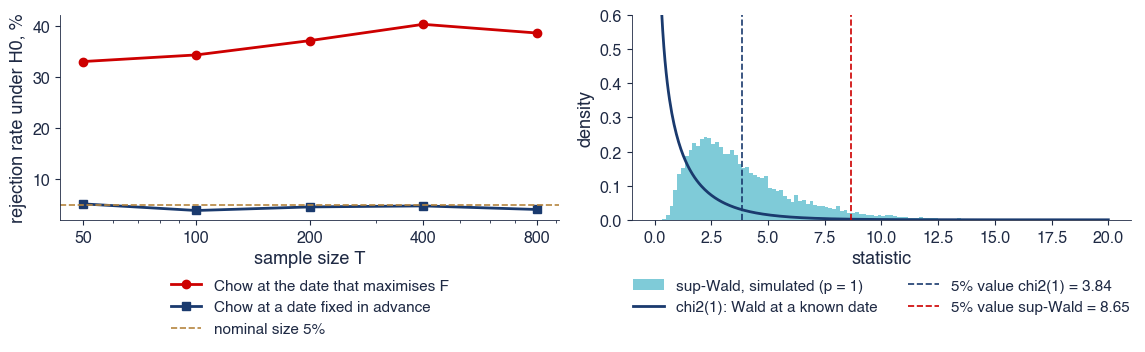

{'Ts': [50, 100, 200, 400, 800], 'fixed': [np.float64(0.052), np.float64(0.039), np.float64(0.046), np.float64(0.048), np.float64(0.041)], 'chosen': [np.float64(0.331), np.float64(0.344), np.float64(0.372), np.float64(0.404), np.float64(0.387)], 'reps': 1000, 'cv': {'sup': {'1': [7.113295196556069, 8.653839926652989, 12.165856955090204], '2': [9.983243676893684, 11.685776598390186, 15.368405234061383]}, 'exp': {'1': [1.4861462502514498, 2.024427644189714, 3.3846717363036465], '2': [2.5739181190589058, 3.2354574079299745, 4.727742902856888]}, 'ave': {'1': [2.132118133557399, 2.8727461621930708, 4.653158713165674], '2': [3.7323371642173733, 4.650053085259943, 6.519319109203465]}}}


In [6]:
def fig_chow_snooping(save_it=True, reps=4000):
    """Size of the Chow F test (5%) at a fixed mid-sample date and at the date that maximises F (the date chosen by
    looking at the data), white noise; and the null density of the sup-Wald statistic against chi2(1)."""
    rng = np.random.default_rng(SEED)
    Ts = [50, 100, 200, 400, 800]
    fixed, chosen = [], []
    for T in Ts:
        h = int(np.floor(TRIM * T))
        rf = rc = 0
        cvF = stats.f.ppf(0.95, 1, T - 2)
        ks = np.arange(h, T - h + 1)
        for _ in range(reps):
            y = rng.standard_normal(T)
            c = np.cumsum(y)
            m1 = c[ks - 1] / ks
            m2 = (c[-1] - c[ks - 1]) / (T - ks)
            ssr0 = y @ y - c[-1] ** 2 / T
            ssr1 = ssr0 - ks * (T - ks) / T * (m1 - m2) ** 2
            F = (ssr0 - ssr1) / (ssr1 / (T - 2))
            rf += F[np.searchsorted(ks, T // 2)] > cvF
            rc += F.max() > cvF
        fixed.append(rf / reps)
        chosen.append(rc / reps)
    nd = null_dist(1)
    nd2 = null_dist(2)
    fig, axs = plt.subplots(1, 2, figsize=(12, 3.9))
    ax = axs[0]
    ax.plot(Ts, 100 * np.array(chosen), 'o-', color=st.IDAred, lw=2, label='Chow at the date that maximises F')
    ax.plot(Ts, 100 * np.array(fixed), 's-', color=st.MainBlue, lw=2, label='Chow at a date fixed in advance')
    ax.axhline(5, color=st.Amber, ls='--', lw=1.2, label='nominal size 5%')
    ax.set_xscale('log')
    ax.set_xticks(Ts)
    ax.set_xticklabels([str(t) for t in Ts])
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.set_xlabel('sample size T')
    ax.set_ylabel('rejection rate under H0, %')
    st.legend_outside_bottom(ax, ncol=1, y=-0.22)
    ax = axs[1]
    x = np.linspace(0.01, 20, 400)
    ax.hist(nd['sup'], bins=120, range=(0, 20), density=True, color=st.Teal, alpha=0.55, label='sup-Wald, simulated (p = 1)')
    ax.plot(x, stats.chi2.pdf(x, 1), color=st.MainBlue, lw=2, label='chi2(1): Wald at a known date')
    c1, c2 = stats.chi2.ppf(0.95, 1), np.quantile(nd['sup'], 0.95)
    ax.axvline(c1, color=st.MainBlue, ls='--', lw=1.2, label=f'5% value chi2(1) = {c1:.2f}')
    ax.axvline(c2, color=st.IDAred, ls='--', lw=1.2, label=f'5% value sup-Wald = {c2:.2f}')
    ax.set_ylim(0, 0.6)
    ax.set_xlabel('statistic')
    ax.set_ylabel('density')
    st.legend_outside_bottom(ax, ncol=2, y=-0.22)
    plt.tight_layout()
    save('ats_ch2_chow_snooping', save_it)
    q = lambda d, a: float(np.quantile(d, a))
    return {'Ts': Ts, 'fixed': fixed, 'chosen': chosen, 'reps': reps,
            'cv': {s: {f'{p}': [q(dd[s], 0.90), q(dd[s], 0.95), q(dd[s], 0.99)] for p, dd in ((1, nd), (2, nd2))}
                   for s in ('sup', 'exp', 'ave')}}


print(fig_chow_snooping(save_it=False, reps=1000))

## 2. The Great Moderation (McConnell and Perez-Quiros 2000)

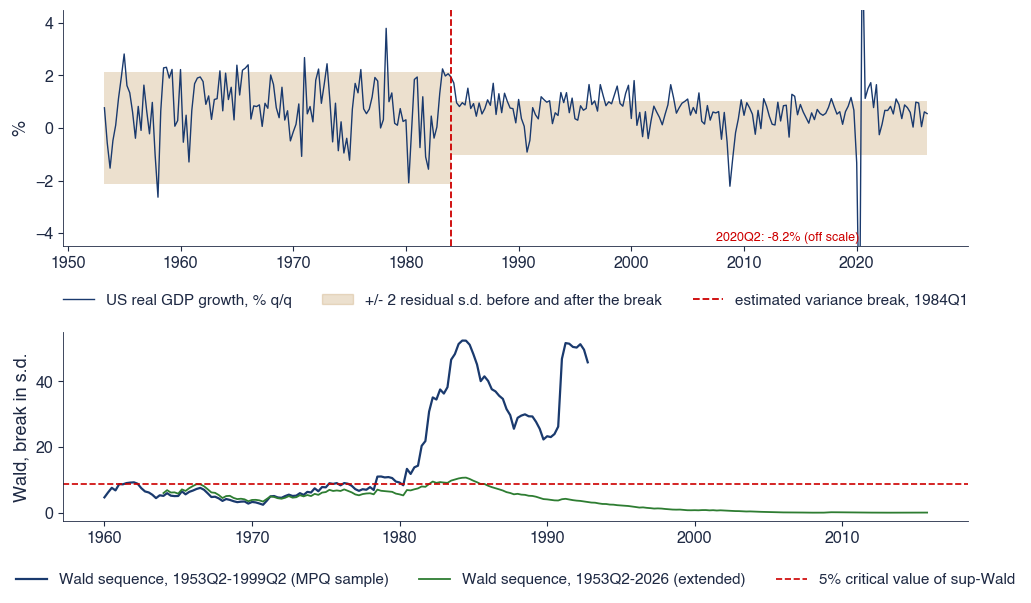

paper 1984Q1 52.5 0.0 5.47
ex2019 1984Q2 50.8 0.0 4.13
ext 1984Q2 10.7 0.0194 1.08


In [7]:
def mpq_test(g, start, end):
    """McConnell and Perez-Quiros (2000) two-step test: AR(1) for quarterly GDP growth, sup/exp/ave-Wald for a break in
    (constant, AR coefficient), then a break in the mean of sqrt(pi/2)|e_t| (a break in the standard deviation)."""
    y0 = g.loc[start:end] if end else g.loc[start:]
    full = g.loc[:y0.index[-1]]
    i0 = full.index.get_loc(y0.index[0])
    yy, X = full.values[i0:], np.column_stack([np.ones(len(y0)), full.values[i0 - 1:-1]])
    dates = y0.index
    b, e, _ = ols(yy, X)
    t_mean, ks_m, W_m = andrews_tests(yy, X, robust='hc')
    v = np.sqrt(np.pi / 2) * np.abs(e)
    t_var, ks_v, W_v = andrews_tests(v, np.ones((len(v), 1)), robust='hac')
    k = t_var['k_hat']                                  # first observation of the second regime
    s_pre, s_post = float(e[:k].std(ddof=1)), float(e[k:].std(ddof=1))
    return {'n': len(yy), 'first': str(dates[0].date()), 'last': str(dates[-1].date()), 'phi': float(b[1]), 'c': float(b[0]),
            'mean': t_mean, 'var': t_var, 'date_var': qlabel(dates[k - 1]), 'date_mean': qlabel(dates[t_mean['k_hat'] - 1]),
            's_pre': s_pre, 's_post': s_post, 'ratio_var': (s_pre / s_post) ** 2}, dates, ks_v, W_v, e


def fig_great_moderation(save_it=True):
    """The Great Moderation: McConnell and Perez-Quiros (2000) on US real GDP growth, 1953Q2-1999Q2 and 1953Q2-2026."""
    g = us_gdp_growth()
    paper, d1, ks1, W1, e1 = mpq_test(g, *MPQ_SAMPLE)
    ext, d2, ks2, W2, e2 = mpq_test(g, MPQ_SAMPLE[0], None)
    ex19, _, _, _, _ = mpq_test(g, MPQ_SAMPLE[0], '2019-10-01')
    fig, axs = plt.subplots(2, 1, figsize=(11, 6.2), gridspec_kw={'height_ratios': [1.25, 1]})
    ax = axs[0]
    y = g.loc[MPQ_SAMPLE[0]:]
    ax.plot(y.index, y.values, color=st.MainBlue, lw=1.0, label='US real GDP growth, % q/q')
    kd = d1[paper['var']['k_hat'] - 1]
    for a, b, s in ((y.index[0], kd, paper['s_pre']), (kd, y.index[-1], ex19['s_post'])):
        ax.fill_between([a, b], [-2 * s] * 2, [2 * s] * 2, color=st.Amber, alpha=0.25, lw=0)
    ax.fill_between([], [], [], color=st.Amber, alpha=0.25, label='+/- 2 residual s.d. before and after the break')
    ax.axvline(kd, color=st.IDAred, ls='--', lw=1.3, label=f'estimated variance break, {paper["date_var"]}')
    ax.set_ylim(-4.5, 4.5)
    ax.set_ylabel('%')
    low = y.idxmin()
    ax.text(low, -4.3, f'{qlabel(low)}: {y.min():.1f}% (off scale)', color=st.IDAred, fontsize=9, ha='right')
    st.legend_outside_bottom(ax, ncol=3, y=-0.14)
    ax = axs[1]
    ax.plot(d1[ks1], W1, color=st.MainBlue, lw=1.6, label='Wald sequence, 1953Q2-1999Q2 (MPQ sample)')
    ax.plot(d2[ks2], W2, color=st.Forest, lw=1.3, label='Wald sequence, 1953Q2-2026 (extended)')
    ax.axhline(paper['var']['cv_sup'], color=st.IDAred, ls='--', lw=1.2, label='5% critical value of sup-Wald')
    ax.set_ylabel('Wald, break in s.d.')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    plt.tight_layout()
    save('ats_ch2_great_moderation', save_it)
    return {'paper': paper, 'ext': ext, 'ex2019': ex19, 'min': float(y.min()), 'min_date': qlabel(y.idxmin())}


r = fig_great_moderation(save_it=False)
for k in ('paper', 'ex2019', 'ext'):
    print(k, r[k]['date_var'], round(r[k]['var']['sup'], 1), r[k]['var']['p_sup'], round(r[k]['ratio_var'], 2))

## 3. Multiple breaks: Bai and Perron (2003) and Romanian inflation

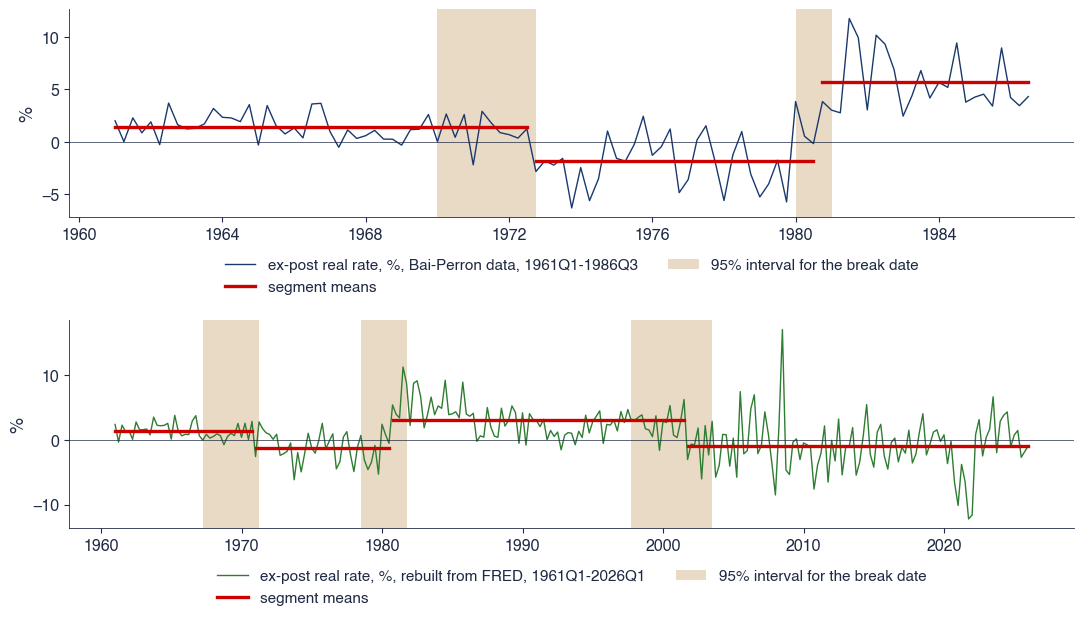

{'m_seq': 3, 'm_bic': 2, 'm_lwz': 2, 'mu': [1.3550372340425532, -1.7961384375, 5.642889583333333], 'ci': [['1970Q1', '1972Q4'], ['1980Q1', '1981Q1']]}
{0: [], 1: ['1980Q3'], 2: ['1972Q3', '1980Q3'], 3: ['1966Q4', '1972Q3', '1980Q3'], 4: ['1966Q4', '1972Q3', '1976Q4', '1980Q3'], 5: ['1964Q4', '1968Q3', '1972Q3', '1976Q4', '1980Q3']}


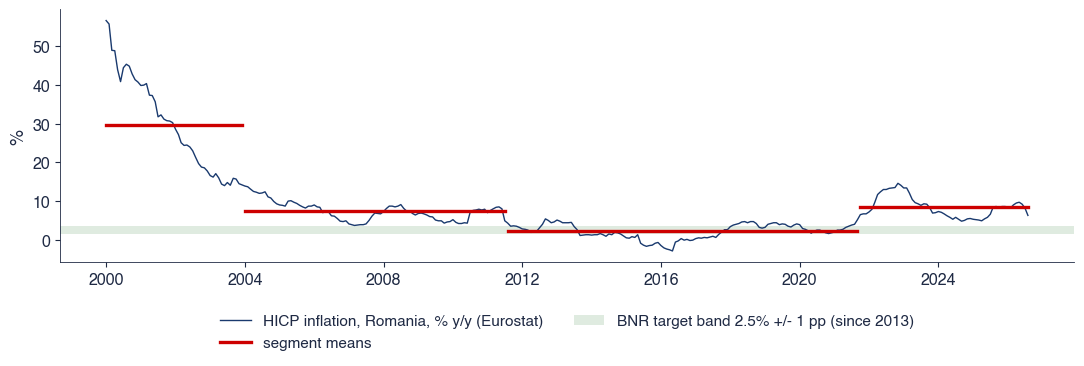

{'n': 320, 'first': '2000-01', 'last': '2026-08', 'h': 48, 'supF': {1: 12.769578038456814, 2: 7.125497557397911, 3: 6.530130682824382, 4: 7.103707769923477, 5: 10.655830478745477}, 'seq': {1: 2.055187250468576}, 'm_seq': 1, 'm_bic': 3, 'm_lwz': 3, 'dates_seq': ['2003-12'], 'mu_seq': [29.78125, 5.301838235294118], 'dates': ['2003-12', '2011-07', '2021-09'], 'mu': [29.78125, 7.450549450549451, 2.154098360655738, 8.496610169491525], 'ci': [['2003-10', '2008-04'], ['2000-01', '2014-12'], ['2000-01', '2026-08']], 'lrv': [2104.660286700095, 126.75031834769923, 357.652629213947, 1399.7571798297024]}


In [8]:
def fig_bai_perron(save_it=True):
    """Bai and Perron (2003, Section 6.1) on the US ex-post real interest rate 1961Q1-1986Q3 (mean shifts, trimming 0.15,
    M = 5, heterogeneous long-run variances), and the same analysis on the series rebuilt from FRED to 2026."""
    cv = bp_cv()
    y = bp_real_rate()
    r = bp_analysis(y.values, M=5, cv=cv)
    m = r['m_seq']
    mb = r['m_bic']
    fit = bp_fit(y.values, r['breaks'][mb])
    fit3 = bp_fit(y.values, r['breaks'][3], ci=False)
    z = us_real_rate()
    over = pd.concat([y, z], axis=1, join='inner')
    corr = float(over.corr().iloc[0, 1])
    rz = bp_analysis(z.values, M=5, cv=cv)
    mz = rz['m_seq']
    fitz = bp_fit(z.values, rz['breaks'][mz])
    fig, axs = plt.subplots(2, 1, figsize=(11, 6.4))
    plot_bp(axs[0], y, fit, st.MainBlue, 'ex-post real rate, %, Bai-Perron data, 1961Q1-1986Q3')
    plot_bp(axs[1], z, fitz, st.Forest, f'ex-post real rate, %, rebuilt from FRED, 1961Q1-{qlabel(z.index[-1])}')
    for ax in axs:
        ax.axhline(0, color=st.DarkText, lw=0.5)
        ax.set_ylabel('%')
        st.legend_outside_bottom(ax, ncol=2, y=-0.13)
    plt.tight_layout()
    save('ats_ch2_bai_perron', save_it)
    lab = lambda s, ks: [qlabel(s.index[k]) for k in ks]
    return {'n': len(y), 'h': r['h'], 'supF': r['supF'], 'UDmax': r['UDmax'], 'seq': r['seq'], 'm_seq': m, 'm_bic': r['m_bic'],
            'm_lwz': r['m_lwz'], 'BIC': r['BIC'], 'LWZ': r['LWZ'], 'ssr': r['ssr'],
            'dates': {k: lab(y, v) for k, v in r['breaks'].items()}, 'mu': fit['mu'], 'ci': ci_dates(y, fit['ci'], qlabel),
            'mu3': fit3['mu'],
            'ext': {'n': len(z), 'last': qlabel(z.index[-1]), 'corr': corr, 'm_seq': mz, 'm_bic': rz['m_bic'], 'm_lwz': rz['m_lwz'],
                    'dates': lab(z, rz['breaks'][mz]), 'mu': fitz['mu'], 'ci': ci_dates(z, fitz['ci'], qlabel),
                    'supF': rz['supF'], 'seq': rz['seq']}}


def fig_ro_inflation_breaks(save_it=True):
    """Bai-Perron mean shifts in Romanian HICP inflation (annual rate, monthly, 2000-2026), M = 5, trimming 0.15."""
    cv = bp_cv()
    y = ro_hicp()
    r = bp_analysis(y.values, M=5, cv=cv)
    m = r['m_seq']
    mb = r['m_bic']
    fit = bp_fit(y.values, r['breaks'][mb])
    fig, ax = plt.subplots(figsize=(11, 3.9))
    plot_bp(ax, y, dict(fit, ci=[]), st.MainBlue, 'HICP inflation, Romania, % y/y (Eurostat)')
    ax.axhspan(1.5, 3.5, color=st.Forest, alpha=0.15, lw=0, label='BNR target band 2.5% +/- 1 pp (since 2013)')
    ax.set_ylabel('%')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    plt.tight_layout()
    save('ats_ch2_ro_inflation_breaks', save_it)
    return {'n': len(y), 'first': mlabel(y.index[0]), 'last': mlabel(y.index[-1]), 'h': r['h'], 'supF': r['supF'],
            'seq': r['seq'], 'm_seq': m, 'm_bic': r['m_bic'], 'm_lwz': r['m_lwz'],
            'dates_seq': [mlabel(y.index[k]) for k in r['breaks'][m]], 'mu_seq': bp_fit(y.values, r['breaks'][m], ci=False)['mu'],
            'dates': [mlabel(y.index[k]) for k in r['breaks'][mb]], 'mu': fit['mu'], 'ci': ci_dates(y, fit['ci'], mlabel),
            'lrv': fit['lrv']}


r = fig_bai_perron(save_it=False)
print({k: r[k] for k in ('m_seq', 'm_bic', 'm_lwz', 'mu', 'ci')})
print(r['dates'])
print(fig_ro_inflation_breaks(save_it=False))

## 4. Real-time monitoring (Chu, Stinchcombe and White 1996)

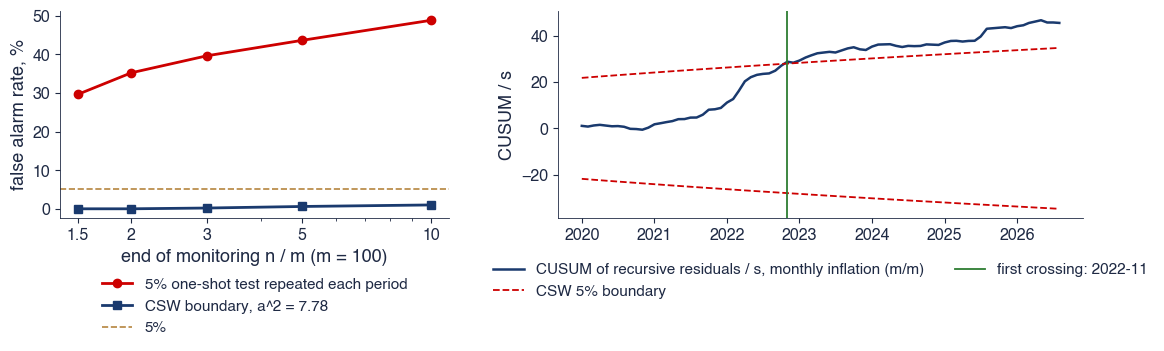

{'mc': {'L': [0.5, 1, 2, 4, 9], 'm': 100, 'naive': [0.296, 0.352, 0.396, 0.436, 0.488], 'csw': [0.0, 0.0, 0.002, 0.006, 0.01], 'reps': 500}, 'size_formula': 0.05078413426079192, 'size_625': 0.10006083311939502, 'm': 60, 'first': '2022-11', 'first_naive': '2022-01', 'first_lr': '2025-08', 's': 0.5097329532371037, 's_lr': 0.6611273850962345, 'mean_hist': 0.14833333333333334, 'end': '2026-08', 'Qend': 45.54916503605599, 'bnd_end': 34.753729302827466}


In [9]:
def fig_monitoring(save_it=True, reps=2000):
    """Size of repeated one-shot tests and of the CSW boundary by simulation; real-time CUSUM monitoring of the mean of
    Romanian monthly HICP inflation (m/m, Eurostat) with the historical sample 2015-2019 (m = 60 months)."""
    mc = monitor_mc(reps=reps)
    y = read_eurostat('prc_hicp_minr', 'M.RCH_M.TOTAL.RO').loc[MON_HIST[0]:]
    yy = y.values
    dates = y.index
    m = int(((dates >= MON_HIST[0]) & (dates <= MON_HIST[1])).sum())
    s = float(yy[:m].std(ddof=1))
    s_lr = float(np.sqrt(lrv_qs(yy[:m])))
    w = recursive_residuals(yy, np.ones((len(yy), 1)))
    t = np.arange(1, len(yy) + 1)
    Q = np.cumsum(np.where(t > m, np.nan_to_num(w), 0.0)) / s
    n = t[m:]
    bnd = csw_boundary(n, m)
    cross = np.where(np.abs(Q[m:]) > bnd)[0]
    first = mlabel(dates[m + cross[0]]) if len(cross) else None
    naive = np.where(np.abs(Q[m:]) > 1.96 * np.sqrt(n - m + 1e-12))[0]
    first_naive = mlabel(dates[m + naive[0]]) if len(naive) else None
    cross_lr = np.where(np.abs(Q[m:] * s / s_lr) > bnd)[0]
    first_lr = mlabel(dates[m + cross_lr[0]]) if len(cross_lr) else None
    fig, axs = plt.subplots(1, 2, figsize=(12, 3.9), gridspec_kw={'width_ratios': [1, 1.35]})
    ax = axs[0]
    hz = 1 + np.array(mc['L'])
    ax.plot(hz, 100 * np.array(mc['naive']), 'o-', color=st.IDAred, lw=2, label='5% one-shot test repeated each period')
    ax.plot(hz, 100 * np.array(mc['csw']), 's-', color=st.MainBlue, lw=2, label='CSW boundary, a^2 = 7.78')
    ax.axhline(5, color=st.Amber, ls='--', lw=1.2, label='5%')
    ax.set_xscale('log')
    ax.set_xticks(hz)
    ax.set_xticklabels([f'{h:g}' for h in hz])
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.set_xlabel('end of monitoring n / m (m = 100)')
    ax.set_ylabel('false alarm rate, %')
    st.legend_outside_bottom(ax, ncol=1, y=-0.22)
    ax = axs[1]
    d = dates[m:]
    ax.plot(d, Q[m:], color=st.MainBlue, lw=1.8, label='CUSUM of recursive residuals / s, monthly inflation (m/m)')
    ax.plot(d, bnd, color=st.IDAred, ls='--', lw=1.3, label='CSW 5% boundary')
    ax.plot(d, -bnd, color=st.IDAred, ls='--', lw=1.3, label='_nolegend_')
    if len(cross):
        ax.axvline(dates[m + cross[0]], color=st.Forest, lw=1.3, label=f'first crossing: {first}')
    ax.set_ylabel('CUSUM / s')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    plt.tight_layout()
    save('ats_ch2_monitoring', save_it)
    return {'mc': mc, 'size_formula': csw_size(A2_5), 'size_625': csw_size(6.25), 'm': m, 'first': first,
            'first_naive': first_naive, 'first_lr': first_lr, 's': s, 's_lr': s_lr, 'mean_hist': float(yy[:m].mean()),
            'end': mlabel(dates[-1]), 'Qend': float(Q[-1]), 'bnd_end': float(bnd[-1])}


print(fig_monitoring(save_it=False, reps=500))

## 5. Breaks in variance: ICSS and kappa-2 on EUR/RON

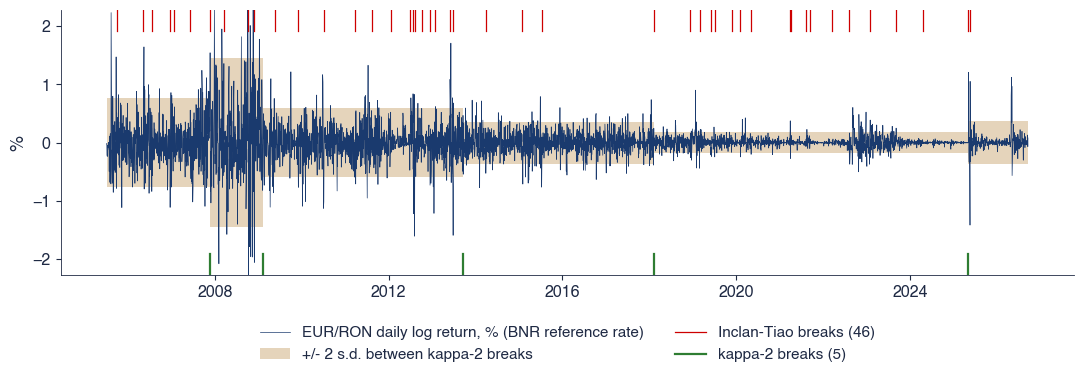

{'n': 5352, 'first': '2005-07-05', 'last': '2026-09-18', 'IT': 23.982578221860635, 'k2': 4.689243824576031, 'n_it': 46, 'n_k2': 5, 'dates_k2': ['2007-11-20', '2009-02-06', '2013-09-19', '2018-02-07', '2025-05-05'], 'dates_it': ['2005-09-28', '2006-05-11', '2006-07-25', '2006-12-20', '2007-01-26', '2007-06-07', '2007-11-20', '2008-03-17', '2008-10-02', '2008-11-28', '2009-05-19', '2009-11-30', '2010-07-06', '2011-03-21', '2011-08-11', '2012-01-18', '2012-06-26', '2012-07-27', '2012-08-07', '2012-10-05', '2012-12-12', '2013-01-28', '2013-05-27', '2013-06-27', '2014-03-28', '2015-01-23', '2015-07-14', '2018-02-07', '2018-12-11', '2019-02-27', '2019-05-30', '2019-07-10', '2019-11-26', '2020-02-05', '2020-05-06', '2021-03-26', '2021-04-08', '2021-08-12', '2021-09-14', '2022-03-16', '2022-08-08', '2023-02-02', '2023-09-06', '2024-04-16', '2025-05-05', '2025-05-22'], 'sd': [0.38159768649074893, 0.7281517675054929, 0.2976391362410538, 0.18060710179480546, 0.08736034463215073, 0.184272192225165

In [10]:
def fig_variance_breaks(save_it=True):
    """ICSS (Inclan-Tiao) and kappa-2 (Sanso-Arago-Carrion) breaks in the variance of daily EUR/RON log returns (BNR)."""
    r = log_returns('eurron')
    a = r.values - r.values.mean()
    b_it = icss(a, 'IT')
    b_k2 = icss(a, 'k2')
    s_it, _ = icss_stat(a, 'IT')
    s_k2, _ = icss_stat(a, 'k2')
    segs = segments(len(a), b_k2)
    sd = [float(a[x:y + 1].std()) for x, y in segs]
    kurt = float(stats.kurtosis(a))
    fig, ax = plt.subplots(figsize=(11, 4.0))
    ax.plot(r.index, r.values, color=st.MainBlue, lw=0.5, label='EUR/RON daily log return, % (BNR reference rate)')
    for i, (x, y) in enumerate(segs):
        ax.fill_between([r.index[x], r.index[y]], [-2 * sd[i]] * 2, [2 * sd[i]] * 2, color=st.Amber, alpha=0.35, lw=0,
                        label='+/- 2 s.d. between kappa-2 breaks' if i == 0 else '_nolegend_')
    for i, k in enumerate(b_it):
        ax.axvline(r.index[k], ymin=0.92, ymax=1.0, color=st.IDAred, lw=0.9,
                   label=f'Inclan-Tiao breaks ({len(b_it)})' if i == 0 else '_nolegend_')
    for i, k in enumerate(b_k2):
        ax.axvline(r.index[k], ymin=0.0, ymax=0.08, color=st.Forest, lw=1.6,
                   label=f'kappa-2 breaks ({len(b_k2)})' if i == 0 else '_nolegend_')
    lim = np.quantile(np.abs(r.values), 0.999) * 1.1
    ax.set_ylim(-lim, lim)
    ax.set_ylabel('%')
    st.legend_outside_bottom(ax, ncol=2, y=-0.14)
    plt.tight_layout()
    save('ats_ch2_variance_breaks', save_it)
    return {'n': len(a), 'first': str(r.index[0].date()), 'last': str(r.index[-1].date()), 'IT': s_it, 'k2': s_k2,
            'n_it': len(b_it), 'n_k2': len(b_k2), 'dates_k2': [str(r.index[k].date()) for k in b_k2],
            'dates_it': [str(r.index[k].date()) for k in b_it], 'sd': sd, 'kurt': kurt}


print(fig_variance_breaks(save_it=False))

## 6. Unit roots with breaks: Romanian GDP

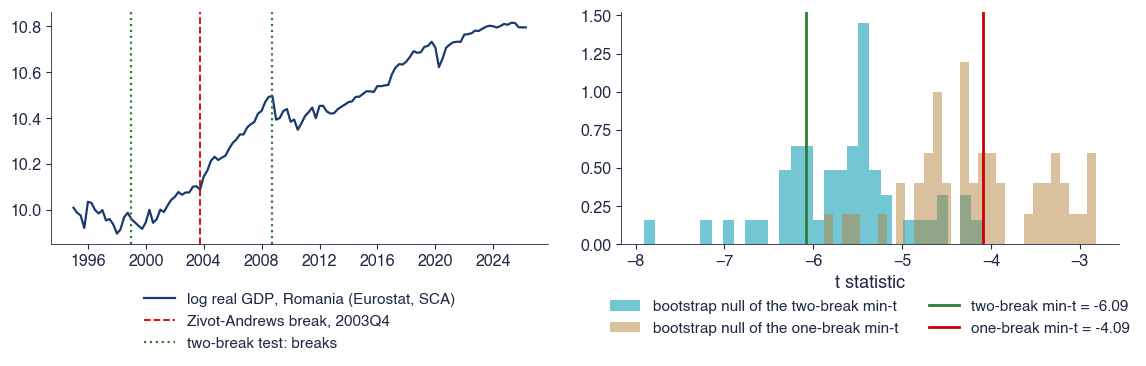

{'n': 126, 'first': '1995Q1', 'last': '2026Q2', 'adf': -2.789986434387235, 'adf_p': 0.2006466398415081, 'adf_lag': 0, 'za': -4.087453828278154, 'za_p': 0.44561190863076133, 'za_cv5': -5.07332, 'za_lag': 0, 'za_date': '2003Q4', 'one_t': -4.087453828166836, 'one_date': '2003Q4', 'p_one': 0.5714285714285714, 'two_t': -6.087140535065065, 'two_dates': ['1999Q1', '2008Q4'], 'p_two': 0.2653061224489796, 'B': 49, 'cv_one_boot': -5.4328640210093155, 'cv_two_boot': -6.798086823744863}


In [11]:
def fig_unit_root_breaks(save_it=True, B=199):
    """ADF, Zivot-Andrews (break in level and trend) and a two-break minimum-t test (model CC of Lumsdaine and Papell 1997)
    with sieve-bootstrap p-values under a unit root without breaks, on the log of Romanian real GDP."""
    from statsmodels.tsa.stattools import adfuller, zivot_andrews
    g = np.log(read_eurostat(*GDP_RO))
    y = g.values
    adf = adfuller(y, maxlag=4, regression='ct', autolag='AIC')
    za = zivot_andrews(y, trim=0.15, maxlag=4, regression='ct', autolag='AIC')
    k = int(za[3])
    ks, ts = min_t_one_break(y, k)
    two, (b1, b2) = min_t_two_breaks(y, k)
    # sieve bootstrap under H0: dy_t = mu + AR(k) noise, no break
    dy = np.diff(y)
    zz, Xd = lags(dy, max(k, 1))
    bd, ed, _ = ols(zz, Xd)
    rng = np.random.default_rng(SEED)
    boot_one, boot_two = [], []
    for _ in range(B):
        eps = rng.choice(ed - ed.mean(), size=len(dy) + 50)
        d = np.zeros(len(dy) + 50)
        p = max(k, 1)
        for i in range(p, len(d)):
            d[i] = bd[0] + bd[1:] @ d[i - p:i][::-1] + eps[i]
        ys = np.concatenate([[y[0]], y[0] + np.cumsum(d[50:])])
        boot_one.append(min_t_one_break(ys, k)[1].min())
        boot_two.append(min_t_two_breaks(ys, k, gap=4)[0])
    p_one = float(np.mean(np.array(boot_one) <= ts.min()))
    p_two = float(np.mean(np.array(boot_two) <= two))
    dates = g.index
    fig, axs = plt.subplots(1, 2, figsize=(12, 3.9))
    ax = axs[0]
    ax.plot(dates, y, color=st.MainBlue, lw=1.6, label='log real GDP, Romania (Eurostat, SCA)')
    ax.axvline(dates[za[4]], color=st.IDAred, ls='--', lw=1.3, label=f'Zivot-Andrews break, {qlabel(dates[za[4]])}')
    for i, b in enumerate((b1, b2)):
        ax.axvline(dates[b], color=st.Forest, ls=':', lw=1.6, label='two-break test: breaks' if i == 0 else '_nolegend_')
    st.legend_outside_bottom(ax, ncol=1, y=-0.15)
    ax = axs[1]
    ax.hist(boot_two, bins=30, color=st.Teal, alpha=0.6, density=True, label='bootstrap null of the two-break min-t')
    ax.hist(boot_one, bins=30, color=st.Amber, alpha=0.5, density=True, label='bootstrap null of the one-break min-t')
    ax.axvline(two, color=st.Forest, lw=2, label=f'two-break min-t = {two:.2f}')
    ax.axvline(ts.min(), color=st.IDAred, lw=2, label=f'one-break min-t = {ts.min():.2f}')
    ax.set_xlabel('t statistic')
    st.legend_outside_bottom(ax, ncol=2, y=-0.18)
    plt.tight_layout()
    save('ats_ch2_unit_root_breaks', save_it)
    return {'n': len(y), 'first': qlabel(dates[0]), 'last': qlabel(dates[-1]), 'adf': float(adf[0]), 'adf_p': float(adf[1]),
            'adf_lag': int(adf[2]), 'za': float(za[0]), 'za_p': float(za[1]), 'za_cv5': float(za[2]['5%']), 'za_lag': k,
            'za_date': qlabel(dates[za[4]]), 'one_t': float(ts.min()), 'one_date': qlabel(dates[ks[ts.argmin()]]),
            'p_one': p_one, 'two_t': float(two), 'two_dates': [qlabel(dates[b1]), qlabel(dates[b2])], 'p_two': p_two,
            'B': B, 'cv_one_boot': float(np.quantile(boot_one, 0.05)), 'cv_two_boot': float(np.quantile(boot_two, 0.05))}


print(fig_unit_root_breaks(save_it=False, B=49))

## 7. Forecasting under breaks: the estimation window

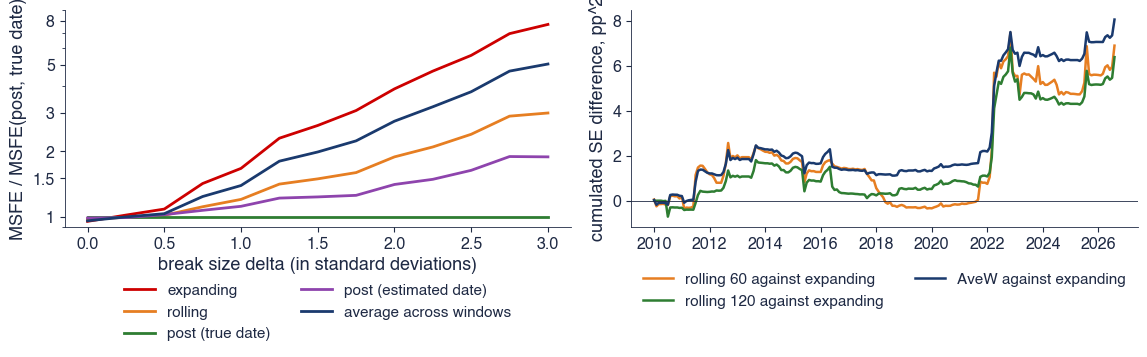

{'expanding': 0.6643857801099605, 'rolling 60': 0.6378735086568744, 'rolling 120': 0.6398765102113119, 'AveW': 0.6333061099329823}
{'rolling 60': {'T': 200, 'dbar': 0.0345258517660892, 'hln': 1.1926193612591158, 'p': 0.2344385795844814}, 'rolling 120': {'T': 200, 'dbar': 0.0319665164921136, 'hln': 1.5683076779737108, 'p': 0.11839805572383548}, 'AveW': {'T': 200, 'dbar': 0.040331835933874155, 'hln': 2.199470654963296, 'p': 0.028996267055665787}}


In [12]:
def fig_forecast_windows(save_it=True, reps=4000):
    """Window choice under breaks: simulation of the relative MSFE, and Romanian inflation forecasts with DM-HLN tests."""
    mc = window_mc(reps=reps)
    F = ro_window_forecasts()
    e = {k: F['y'] - F[k] for k in ('expanding', 'rolling 60', 'rolling 120', 'AveW')}
    rmse = {k: float(np.sqrt(np.mean(v ** 2))) for k, v in e.items()}
    sub = slice('2021-01-01', '2023-12-01')
    rmse_sub = {k: float(np.sqrt(np.mean(v.loc[sub] ** 2))) for k, v in e.items()}
    dm = {k: dm_hln(e['expanding'] ** 2 - e[k] ** 2) for k in ('rolling 60', 'rolling 120', 'AveW')}
    fig, axs = plt.subplots(1, 2, figsize=(12, 3.9))
    ax = axs[0]
    cols = {'expanding': st.IDAred, 'rolling': st.Orange, 'post (true date)': st.Forest, 'post (estimated date)': st.Purple,
            'average across windows': st.MainBlue}
    for k, v in mc['rel'].items():
        ax.plot(mc['deltas'], v, color=cols[k], lw=2, label=k)
    ax.set_yscale('log')
    ax.set_ylim(0.9, 9)
    ax.set_yticks([1, 1.5, 2, 3, 5, 8])
    ax.set_yticklabels(['1', '1.5', '2', '3', '5', '8'])
    ax.yaxis.set_minor_formatter(plt.NullFormatter())
    ax.set_xlabel('break size delta (in standard deviations)')
    ax.set_ylabel('MSFE / MSFE(post, true date)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    ax = axs[1]
    for k, c in (('rolling 60', st.Orange), ('rolling 120', st.Forest), ('AveW', st.MainBlue)):
        ax.plot(F.index, np.cumsum(e['expanding'] ** 2 - e[k] ** 2), color=c, lw=1.8, label=f'{k} against expanding')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_ylabel('cumulated SE difference, pp^2')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    plt.tight_layout()
    save('ats_ch2_forecast_windows', save_it)
    return {'mc': mc, 'n': len(F), 'first': mlabel(F.index[0]), 'last': mlabel(F.index[-1]), 'rmse': rmse,
            'rmse_sub': rmse_sub, 'dm': dm}


r = fig_forecast_windows(save_it=False, reps=1000)
print(r['rmse'])
print(r['dm'])

## 8. Threshold autoregression: the lynx (Tong and Lim 1980) and US unemployment (Hansen 1997)

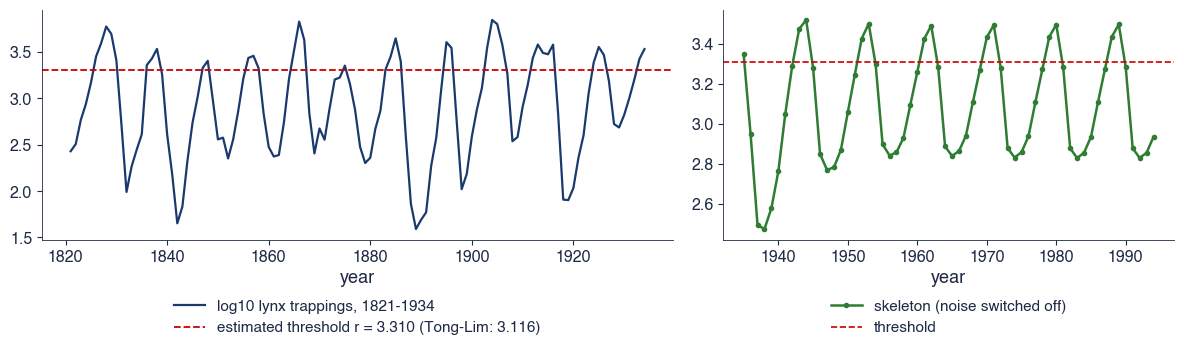

{'gamma': 3.3100557377508912, 'b1': [0.5578672000486519, 1.051374039520876, -0.19161910998293272, 0.0721441519050319, -0.2757885977848022, 0.17065528287884937, -0.18971194892037962, 0.20469358935731616], 'b2': [1.1656919479037149, 1.5992540700908267, -1.0115754904951981], 'n1': 73, 'n2': 34, 'ssr': 3.7640049714721697, 'period': 9.0, 'aic_setar': -334.165946238083, 'b1_tl': [0.545814357090901, 1.03204091464072, -0.17298993776265334, 0.17065064167737534, -0.43106030816195406, 0.332435605590148, -0.2841481462741427, 0.20951077068134416], 'b2_tl': [2.3451509619787423, 1.5326688308553602, -1.2755768908271397], 'ssr_tl': 3.943284027421269, 'n': 107, 'resvar_setar': 0.03517761655581467, 'resvar_ar11': 0.036449796881694564}


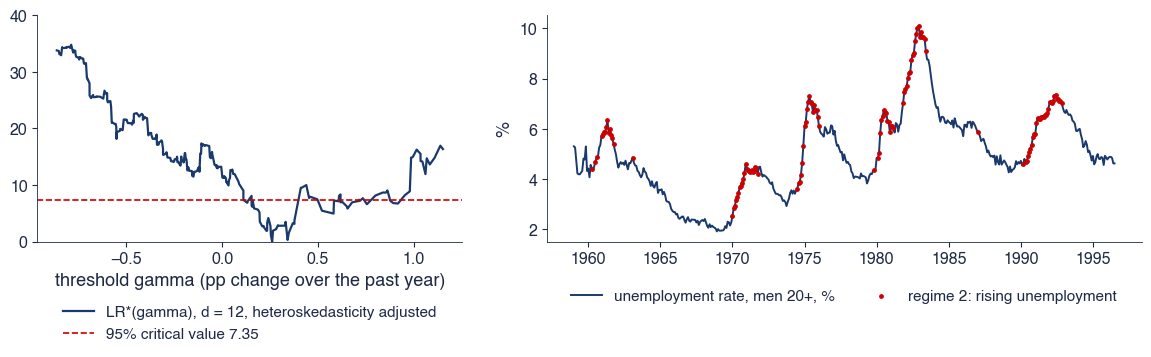

{'gamma': 0.260838514924818, 'ci': [0.13115831071734174, 0.9172260159706265], 'n1': 314, 'n2': 124, 'p12': 0.015, 'dhat': 3}


In [13]:
def fig_lynx(save_it=True):
    L = lynx_setar()
    y = L['y']
    fig, axs = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={'width_ratios': [1.4, 1]})
    ax = axs[0]
    ax.plot(y.index, y.values, color=st.MainBlue, lw=1.6, label='log10 lynx trappings, 1821-1934')
    ax.axhline(L['gamma'], color=st.IDAred, ls='--', lw=1.3, label=f'estimated threshold r = {L["gamma"]:.3f} (Tong-Lim: 3.116)')
    ax.set_xlabel('year')
    st.legend_outside_bottom(ax, ncol=1, y=-0.2)
    ax = axs[1]
    yrs = np.arange(y.index[-1] + 1, y.index[-1] + 1 + len(L['skeleton']))
    ax.plot(yrs, L['skeleton'], color=st.Forest, lw=1.8, marker='o', ms=3, label='skeleton (noise switched off)')
    ax.axhline(L['gamma'], color=st.IDAred, ls='--', lw=1.2, label='threshold')
    ax.set_xlabel('year')
    st.legend_outside_bottom(ax, ncol=1, y=-0.2)
    plt.tight_layout()
    save('ats_ch2_lynx', save_it)
    return {k: (v.tolist() if isinstance(v, np.ndarray) else v) for k, v in L.items() if k not in ('y', 'skeleton')}


def fig_unemp_tar(save_it=True, B=300):
    """Hansen (1997) TAR for the US unemployment rate of men aged 20 and over, 1959.1-1996.7: SSE and bootstrap p-value of
    the robust sup-Wald test for q = y_{t-1} - y_{t-d}, d = 2..12; threshold estimate and LR confidence interval for the
    selected d; the same model on 1959-2019."""
    rows = []
    for d in range(2, 13):
        y, X, q, _ = unemp_tar_data(*HANSEN_SAMPLE, d=d)
        S = tar_ssr(y, X, q, threshold_grid(q))
        ht = hansen_test(y, X, q, B=B, every=2)
        rows.append({'d': d, 'sse': float(S.min()), 'p': ht['p'], 'supW': ht['supW']})
    dhat = min(rows, key=lambda r: r['sse'])['d']
    y, X, q, dates = unemp_tar_data(*HANSEN_SAMPLE, d=12)        # the specification of Hansen (1997): d = 12
    est = tar_estimate(y, X, q)
    ht = hansen_test(y, X, q, B=1000)
    lin_sse = ols(y, X)[2]
    yd, Xd, qd, _ = unemp_tar_data(*HANSEN_SAMPLE, d=dhat)
    estd = tar_estimate(yd, Xd, qd)
    y2, X2, q2, dates2 = unemp_tar_data(HANSEN_SAMPLE[0], '2019-12-01', d=12)
    est2 = tar_estimate(y2, X2, q2)
    ht2 = hansen_test(y2, X2, q2, B=B, every=2)
    fig, axs = plt.subplots(1, 2, figsize=(12, 3.9), gridspec_kw={'width_ratios': [1, 1.4]})
    ax = axs[0]
    ax.plot(est['gammas'], est['LR'], color=st.MainBlue, lw=1.6, label='LR*(gamma), d = 12, heteroskedasticity adjusted')
    ax.axhline(est['crit'], color=st.IDAred, ls='--', lw=1.2, label=f'95% critical value {est["crit"]:.2f}')
    ax.set_xlabel('threshold gamma (pp change over the past year)')
    ax.set_ylim(0, 40)
    st.legend_outside_bottom(ax, ncol=1, y=-0.22)
    ax = axs[1]
    u = unemp_men(True).loc[HANSEN_SAMPLE[0]:HANSEN_SAMPLE[1]]
    ax.plot(u.index, u.values, color=st.MainBlue, lw=1.4, label='unemployment rate, men 20+, %')
    reg2 = q > est['gamma']
    ax.scatter(dates[reg2], u.loc[dates[reg2]].values, s=6, color=st.IDAred, zorder=3, label='regime 2: rising unemployment')
    ax.set_ylabel('%')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    plt.tight_layout()
    save('ats_ch2_unemp_tar', save_it)
    return {'rows': rows, 'dhat': dhat, 'gamma': est['gamma'], 'ci': est['ci'], 'n': len(y), 'n1': est['n1'], 'n2': est['n2'],
            'b1': est['b1'][:3].tolist(), 'b2': est['b2'][:3].tolist(), 'sse': est['ssr'], 'lin_sse': float(lin_sse),
            'p12': ht['p'], 'supW12': ht['supW'], 'B12': ht['B'], 'eta2': est['eta2'],
            'first': mlabel(dates[0]), 'last': mlabel(dates[-1]), 'B': B,
            'dhat_fit': {'gamma': estd['gamma'], 'ci': estd['ci'], 'n2': estd['n2']},
            'ext': {'n': len(y2), 'gamma': est2['gamma'], 'ci': est2['ci'], 'p': ht2['p'], 'n2': est2['n2']}}


print(fig_lynx(save_it=False))
r = fig_unemp_tar(save_it=False, B=100)
print({k: r[k] for k in ('gamma', 'ci', 'n1', 'n2', 'p12', 'dhat')})

## 9. Smooth transition: LSTAR for unemployment and ESTAR for the real exchange rate

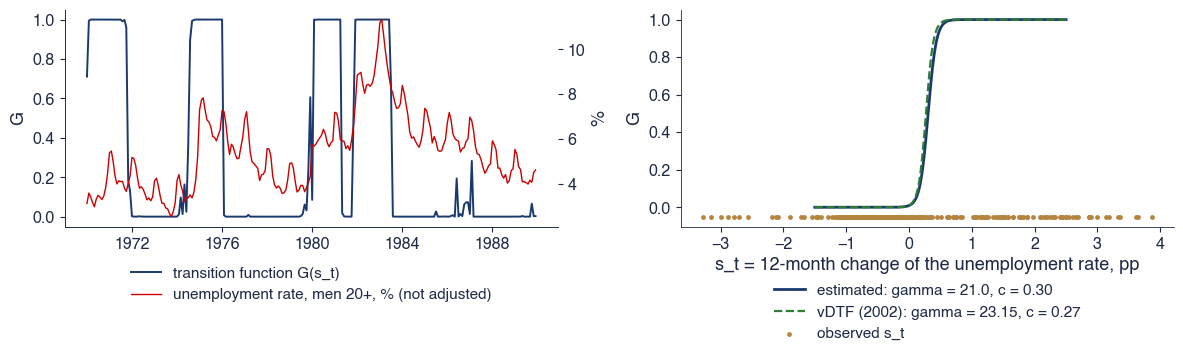

{'gamma': 20.989294812556324, 'c': 0.3047243962333769, 'ratio_sd': 0.902581469886188, 'rmse_star': 0.21821728318077846, 'rmse_lin': 0.228074913988659}


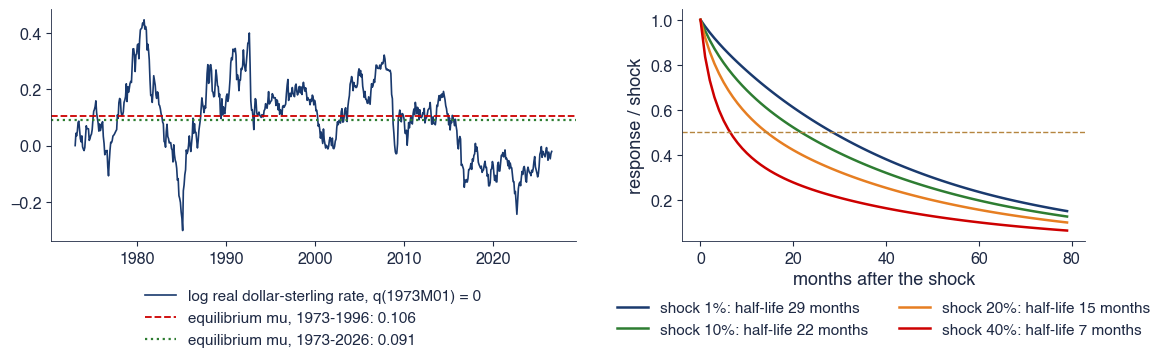

{'theta2': 0.5273791844885184, 'mu': 0.1062877519908426, 'se': [0.21859876043600032, 0.04005064993001053], 's': 0.033128429687617464, 'n': 287, 'ssr': 0.312785463266713}
{'0.01': 29, '0.05': 26, '0.10': 22, '0.20': 15, '0.30': 10, '0.40': 7} 0.165


In [14]:
def fig_unemp_lstar(save_it=True):
    """vDTF (2002, Section 7): LM linearity tests for d = 1..6, the LSTAR model with s_t = y_{t-1} - y_{t-13}, and
    one-step forecasts 1990-1999 with the parameters fixed at the 1989 estimates."""
    tests = {}
    for d in range(1, 7):
        y, Xc, W, s, _ = vdtf_data(d=d)
        tests[d] = lm3_test(y, np.column_stack([Xc, W]), W, s)
    y, Xc, W, s, dates = vdtf_data(d=1)
    Xl = np.column_stack([Xc, W])
    bl, el, ssr_l = ols(y, Xl)
    fit = star_fit(y, Xc, W, s)
    n = len(y)
    kl = Xl.shape[1]
    aic = lambda S, k: float(np.log(S / n) + 2 * k / n)
    bic = lambda S, k: float(np.log(S / n) + k * np.log(n) / n)
    # out of sample, 1990.1-1999.12, parameters fixed
    yo, Xco, Wo, so, do = vdtf_data(end=VDTF_SAMPLE[1], start_est='1990-01-01', d=1)
    f_star = star_predict(fit, Xco, Wo, so)
    f_lin = np.column_stack([Xco, Wo]) @ bl
    e_s, e_l = yo - f_star, yo - f_lin
    dm = dm_hln(e_l ** 2 - e_s ** 2)
    fig, axs = plt.subplots(1, 2, figsize=(12, 3.9))
    ax = axs[0]
    ax.plot(dates, fit['G'], color=st.MainBlue, lw=1.4, label='transition function G(s_t)')
    ax2 = ax.twinx()
    u = unemp_men(False).loc[dates[0]:dates[-1]]
    ax2.plot(u.index, u.values, color=st.IDAred, lw=1.0, label='unemployment rate, men 20+, % (not adjusted)')
    ax.set_ylabel('G')
    ax2.set_ylabel('%')
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=1, frameon=False)
    ax = axs[1]
    ss = np.linspace(-1.5, 2.5, 300)
    ax.plot(ss, logistic(ss, fit['gamma'], fit['c'], fit['sd']), color=st.MainBlue, lw=2,
            label=f'estimated: gamma = {fit["gamma"]:.1f}, c = {fit["c"]:.2f}')
    ax.plot(ss, logistic(ss, 23.15, 0.27, fit['sd']), color=st.Forest, lw=1.6, ls='--', label='vDTF (2002): gamma = 23.15, c = 0.27')
    ax.scatter(s, np.full(len(s), -0.05), s=6, color=st.Amber, label='observed s_t')
    ax.set_xlabel('s_t = 12-month change of the unemployment rate, pp')
    ax.set_ylabel('G')
    st.legend_outside_bottom(ax, ncol=1, y=-0.2)
    plt.tight_layout()
    save('ats_ch2_unemp_lstar', save_it)
    return {'tests': tests, 'n': n, 'gamma': fit['gamma'], 'c': fit['c'], 'sd_s': fit['sd'],
            'ratio_sd': float(np.sqrt(fit['ssr'] / ssr_l)), 'aic_lin': aic(ssr_l, kl), 'aic_star': aic(fit['ssr'], fit['k']),
            'bic_lin': bic(ssr_l, kl), 'bic_star': bic(fit['ssr'], fit['k']), 'k_lin': kl, 'k_star': fit['k'],
            'sigma_lin': float(np.sqrt(ssr_l / (n - kl))), 'sigma_star': float(np.sqrt(fit['ssr'] / (n - fit['k']))),
            'oos_n': len(yo), 'rmse_star': float(np.sqrt(np.mean(e_s ** 2))), 'rmse_lin': float(np.sqrt(np.mean(e_l ** 2))),
            'dm': dm, 'share_G': float(np.mean(fit['G'] > 0.5))}


def fig_ppp_estar(save_it=True, reps=2000):
    """Taylor, Peel and Sarno (2001) on the real dollar-sterling rate: ESTAR estimates on 1973M01-1996M12 and on the
    extended sample, Monte Carlo p-value of the theta t-ratio under a random walk, half-lives by shock size, the power of the
    Dickey-Fuller test against the estimated ESTAR."""
    from statsmodels.tsa.stattools import adfuller
    q = real_usd_gbp()
    qp = q.loc[:TPS_SAMPLE[1]].values
    fp = estar_fit(qp)
    fe = estar_fit(q.values)
    df_p = adfuller(qp, maxlag=0, regression='c', autolag=None)
    df_e = adfuller(q.values, maxlag=0, regression='c', autolag=None)
    girf_p = estar_girf(fp['theta2'], fp['mu'], fp['s'], reps=reps)
    girf_e = estar_girf(fe['theta2'], fe['mu'], fe['s'], reps=reps)
    girh_p = estar_girf_history(fp['theta2'], fp['mu'], fp['s'], qp)
    girh_e = estar_girf_history(fe['theta2'], fe['mu'], fe['s'], q.values)
    rho = ols(qp[1:], np.column_stack([np.ones(len(qp) - 1), qp[:-1]]))[0][1]
    hl_ar = float(np.log(0.5) / np.log(rho))
    power = df_power_estar(fp['theta2'], fp['s'], T=len(qp), reps=reps // 2)
    power_paper = df_power_estar(0.452, 0.033, T=288, reps=reps // 2)     # Table 3a parameters of the paper
    kn_p, kn_e = kss_null(len(qp)), kss_null(len(q))
    # Monte Carlo p-value of the t-ratio of theta^2 under a random walk calibrated on the data
    rng = np.random.default_rng(SEED)
    sd_rw = float(np.diff(qp).std())
    tr = fp['theta2'] / fp['se'][0]
    tsim = []
    for _ in range(200):
        x = np.cumsum(rng.normal(0, sd_rw, len(qp)))
        x = x - x[0]
        f = estar_fit(x)
        tsim.append(f['theta2'] / f['se'][0])
    p_mc = float(np.mean(np.array(tsim) >= tr))
    fig, axs = plt.subplots(1, 2, figsize=(12, 3.9), gridspec_kw={'width_ratios': [1.3, 1]})
    ax = axs[0]
    ax.plot(q.index, q.values, color=st.MainBlue, lw=1.2, label='log real dollar-sterling rate, q(1973M01) = 0')
    ax.axhline(fp['mu'], color=st.IDAred, ls='--', lw=1.3, label=f'equilibrium mu, 1973-1996: {fp["mu"]:.3f}')
    ax.axhline(fe['mu'], color=st.Forest, ls=':', lw=1.6, label=f'equilibrium mu, 1973-{str(q.index[-1].year)}: {fe["mu"]:.3f}')
    st.legend_outside_bottom(ax, ncol=1, y=-0.15)
    ax = axs[1]
    for k, c in zip(('0.01', '0.10', '0.20', '0.40'), (st.MainBlue, st.Forest, st.Orange, st.IDAred)):
        ax.plot(np.arange(len(girh_p[k]['irf'])), girh_p[k]['irf'], color=c, lw=1.8,
                label=f'shock {int(round(100 * float(k)))}%: half-life {girh_p[k]["half_life"]} months')
    ax.axhline(0.5, color=st.Amber, ls='--', lw=1)
    ax.set_xlabel('months after the shock')
    ax.set_ylabel('response / shock')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    plt.tight_layout()
    save('ats_ch2_ppp_estar', save_it)
    hl = lambda G: {k: v['half_life'] for k, v in G.items()}
    return {'paper': {k: v for k, v in fp.items() if k != 'e'}, 'ext': {k: v for k, v in fe.items() if k != 'e'},
            'last': mlabel(q.index[-1]), 'df_p': float(df_p[0]), 'df_pp': float(df_p[1]), 'df_e': float(df_e[0]),
            'df_ep': float(df_e[1]), 'hl_p': hl(girf_p), 'hl_e': hl(girf_e), 'hlh_p': hl(girh_p), 'hlh_e': hl(girh_e),
            'hl_ar': hl_ar, 'rho_ar': float(rho), 'power': power, 'p_mc': p_mc, 't_theta': float(tr),
            'kss_p': kss_stat(qp), 'kss_e': kss_stat(q.values), 'power_paper': power_paper,
            'kss_cv_p': float(np.quantile(kn_p, 0.05)), 'kss_cv_e': float(np.quantile(kn_e, 0.05)),
            'kss_pp': float(np.mean(kn_p <= kss_stat(qp))), 'kss_pe': float(np.mean(kn_e <= kss_stat(q.values)))}


r = fig_unemp_lstar(save_it=False)
print({k: r[k] for k in ('gamma', 'c', 'ratio_sd', 'rmse_star', 'rmse_lin')})
r = fig_ppp_estar(save_it=False, reps=400)
print(r['paper'])
print(r['hlh_p'], r['p_mc'])

## 10. Nonlinearity tests

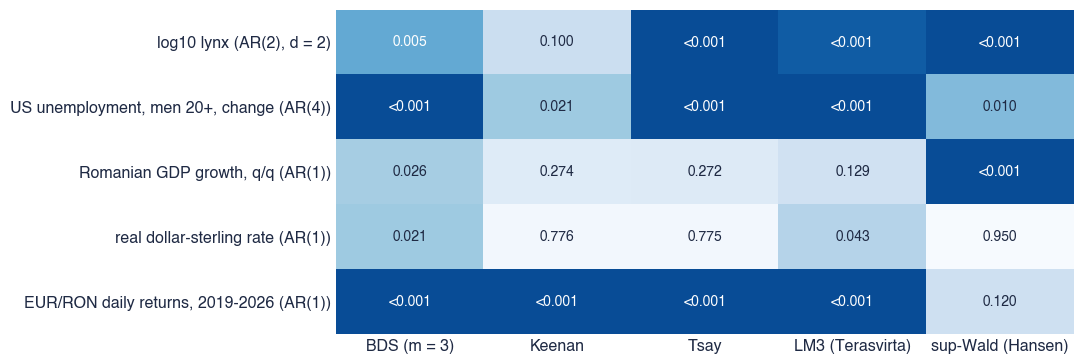

log10 lynx (AR(2), d = 2) {'bds_p': 0.005, 'keenan_p': 0.1, 'tsay_p': 0.0, 'lm3_p': 0.0, 'supW_p': 0.0}
US unemployment, men 20+, change (AR(4)) {'bds_p': 0.0, 'keenan_p': 0.021, 'tsay_p': 0.0, 'lm3_p': 0.0, 'supW_p': 0.01}
Romanian GDP growth, q/q (AR(1)) {'bds_p': 0.026, 'keenan_p': 0.274, 'tsay_p': 0.272, 'lm3_p': 0.129, 'supW_p': 0.0}
real dollar-sterling rate (AR(1)) {'bds_p': 0.021, 'keenan_p': 0.776, 'tsay_p': 0.775, 'lm3_p': 0.043, 'supW_p': 0.95}
EUR/RON daily returns, 2019-2026 (AR(1)) {'bds_p': 0.0, 'keenan_p': 0.0, 'tsay_p': 0.0, 'lm3_p': 0.0, 'supW_p': 0.12}


In [15]:
def fig_nonlinearity_tests(save_it=True, B=200):
    """The test battery on five series: lynx, US unemployment changes, Romanian GDP growth, the real dollar-sterling rate,
    daily EUR/RON returns."""
    series = {
        'log10 lynx (AR(2), d = 2)': (lynx().values, 2, 2),
        'US unemployment, men 20+, change (AR(4))': (np.diff(unemp_men(True).loc[HANSEN_SAMPLE[0]:'2019-12-01'].values), 4, 1),
        'Romanian GDP growth, q/q (AR(1))': (np.diff(100 * np.log(read_eurostat(*GDP_RO).values)), 1, 1),
        'real dollar-sterling rate (AR(1))': (real_usd_gbp().values, 1, 1),
        'EUR/RON daily returns, 2019-2026 (AR(1))': (log_returns('eurron', '2019-01-01').values, 1, 1),
    }
    res = {k: nl_battery(v[0], v[1], v[2], B=B) for k, v in series.items()}
    tests = [('bds_p', 'BDS (m = 3)'), ('keenan_p', 'Keenan'), ('tsay_p', 'Tsay'), ('lm3_p', 'LM3 (Terasvirta)'),
             ('supW_p', 'sup-Wald (Hansen)')]
    M = np.array([[res[k][t] for t, _ in tests] for k in series])
    fig, ax = plt.subplots(figsize=(11, 3.8))
    ax.imshow(-np.log10(np.maximum(M, 1e-4)), cmap='Blues', vmin=0, vmax=4.5, aspect='auto')
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M[i, j]
            ax.text(j, i, '<0.001' if v < 0.001 else f'{v:.3f}', ha='center', va='center', fontsize=10,
                    color='white' if v < 0.01 else st.DarkText)
    ax.set_xticks(range(len(tests)))
    ax.set_xticklabels([t for _, t in tests])
    ax.set_yticks(range(len(series)))
    ax.set_yticklabels(list(series))
    ax.tick_params(length=0)
    for sp in ax.spines.values():
        sp.set_visible(False)
    plt.tight_layout()
    save('ats_ch2_nonlinearity_tests', save_it)
    return {k: v for k, v in zip(series, res.values())}


r = fig_nonlinearity_tests(save_it=False, B=100)
for k, v in r.items():
    print(k, {t: round(v[t], 3) for t in ('bds_p', 'keenan_p', 'tsay_p', 'lm3_p', 'supW_p')})

## 11. Nonlinear forecasts of US unemployment

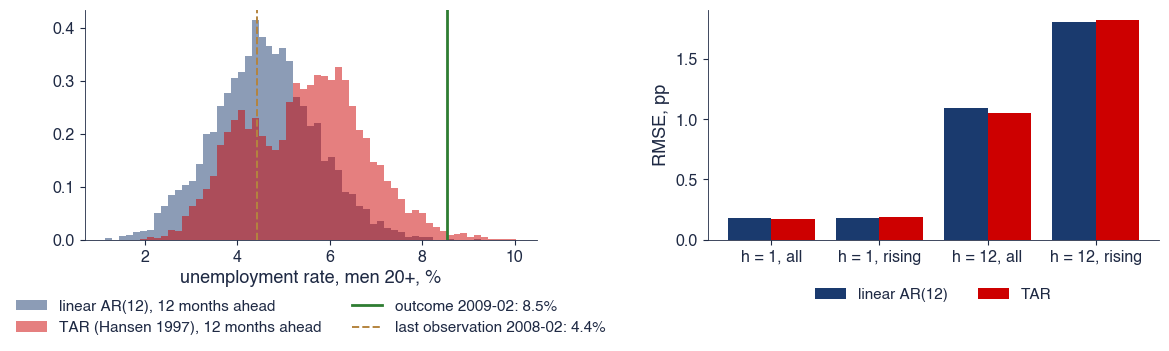

{'n': 270, 'rmse_tar': 0.1731870069022443, 'rmse_ar': 0.17824831781931313, 'dm': {'T': 270, 'dbar': 0.001778723445656845, 'hln': 1.3919459707813693, 'p': 0.16508852966648874}, 'n_reg2': 62, 'rmse_tar_reg2': 0.18498828980380955, 'rmse_ar_reg2': 0.18186025902464828}
{'n': 270, 'rmse_tar': 1.0473794775203191, 'rmse_ar': 1.0909684125176988, 'dm': {'T': 270, 'dbar': 0.09320830718065118, 'hln': 0.49310022218287203, 'p': 0.6223440626158985}, 'n_reg2': 62, 'rmse_tar_reg2': 1.8194608359945628, 'rmse_ar_reg2': 1.805392003657851}


In [16]:
def fig_nonlinear_forecasts(save_it=True, n_paths=500, origin='2008-03-01'):
    """Out-of-sample forecasts of the unemployment rate of men 20+ (levels), 1996.8-2019.12, from the TAR of Hansen (1997,
    d = 12, parameters fixed at the 1959-1996 estimates) and a linear AR(12) in differences: RMSE at 1 and 12 months,
    overall and when the TAR is in the rising-unemployment regime; simulated 12-month forecast densities at one origin."""
    y, X, q, dates = unemp_tar_data(*HANSEN_SAMPLE, d=12)
    est = tar_estimate(y, X, q)
    est['q_reg'] = q
    bl, el, _ = ols(y, X)
    u = unemp_men(True).loc[HANSEN_SAMPLE[0]:'2019-12-01']
    lev = u.values
    idx = u.index
    rng = np.random.default_rng(SEED)
    i0 = int(np.searchsorted(idx, pd.Timestamp('1996-08-01')))
    res = {1: [], 12: []}
    for i in range(i0, len(lev) - 1):
        hist = lev[i - 13:i]
        if i + 12 > len(lev):
            break
        T_ = tar_paths(est, hist, 12, n_paths, rng)
        A_ = ar_paths(bl, el, hist, 12, n_paths, rng)
        reg = (hist[-1] - hist[-12]) > est['gamma']
        for h in (1, 12):
            if i + h - 1 < len(lev):
                res[h].append((idx[i + h - 1], lev[i + h - 1], T_[:, h - 1].mean(), A_[:, h - 1].mean(), reg))
    out = {}
    for h in (1, 12):
        R = pd.DataFrame(res[h], columns=['date', 'y', 'tar', 'ar', 'reg']).set_index('date')
        et, ea = R['y'] - R['tar'], R['y'] - R['ar']
        out[h] = {'n': len(R), 'rmse_tar': float(np.sqrt(np.mean(et ** 2))), 'rmse_ar': float(np.sqrt(np.mean(ea ** 2))),
                  'dm': dm_hln(ea ** 2 - et ** 2, h), 'n_reg2': int(R['reg'].sum()),
                  'rmse_tar_reg2': float(np.sqrt(np.mean(et[R['reg']] ** 2))), 'rmse_ar_reg2': float(np.sqrt(np.mean(ea[R['reg']] ** 2)))}
    j = int(np.searchsorted(idx, pd.Timestamp(origin)))
    hist = lev[j - 13:j]
    T_ = tar_paths(est, hist, 12, 5000, rng)[:, -1]
    A_ = ar_paths(bl, el, hist, 12, 5000, rng)[:, -1]
    actual = float(lev[j + 11])
    fig, axs = plt.subplots(1, 2, figsize=(12, 3.8))
    ax = axs[0]
    bins = np.linspace(min(T_.min(), A_.min()), max(T_.max(), A_.max(), actual + 0.5), 60)
    ax.hist(A_, bins=bins, density=True, color=st.MainBlue, alpha=0.5, label='linear AR(12), 12 months ahead')
    ax.hist(T_, bins=bins, density=True, color=st.IDAred, alpha=0.5, label='TAR (Hansen 1997), 12 months ahead')
    ax.axvline(actual, color=st.Forest, lw=2, label=f'outcome {mlabel(idx[j + 11])}: {actual:.1f}%')
    ax.axvline(lev[j - 1], color=st.Amber, ls='--', lw=1.4, label=f'last observation {mlabel(idx[j - 1])}: {lev[j - 1]:.1f}%')
    ax.set_xlabel('unemployment rate, men 20+, %')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    ax = axs[1]
    labels = ['h = 1, all', 'h = 1, rising', 'h = 12, all', 'h = 12, rising']
    tar_v = [out[1]['rmse_tar'], out[1]['rmse_tar_reg2'], out[12]['rmse_tar'], out[12]['rmse_tar_reg2']]
    ar_v = [out[1]['rmse_ar'], out[1]['rmse_ar_reg2'], out[12]['rmse_ar'], out[12]['rmse_ar_reg2']]
    xx = np.arange(4)
    ax.bar(xx - 0.2, ar_v, 0.4, color=st.MainBlue, label='linear AR(12)')
    ax.bar(xx + 0.2, tar_v, 0.4, color=st.IDAred, label='TAR')
    ax.set_xticks(xx)
    ax.set_xticklabels(labels)
    ax.set_ylabel('RMSE, pp')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    plt.tight_layout()
    save('ats_ch2_nonlinear_forecasts', save_it)
    out['origin'] = mlabel(idx[j - 1])
    out['actual'] = actual
    out['tar_mean'], out['ar_mean'] = float(T_.mean()), float(A_.mean())
    out['tar_q'] = np.quantile(T_, [0.05, 0.95]).tolist()
    out['ar_q'] = np.quantile(A_, [0.05, 0.95]).tolist()
    out['first'] = mlabel(idx[i0])
    return out


r = fig_nonlinear_forecasts(save_it=False, n_paths=200)
print(r[1])
print(r[12])

## 12. AI mini-case: ESTAR evidence or mean shifts?

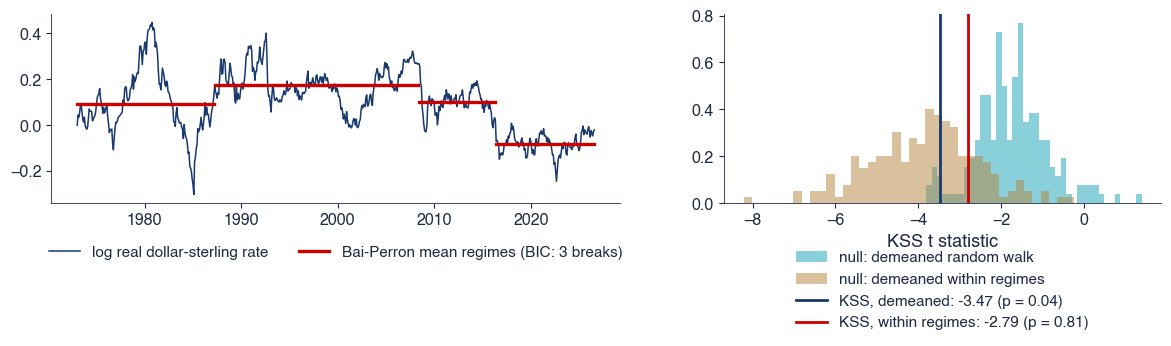

{'T': 643, 'm': 3, 'dates': ['1987-03', '2008-05', '2016-05'], 'k_raw': -3.473858882164534, 'k_seg': -2.787718844759792, 'p_raw': 0.04, 'p_seg': 0.805, 'reps': 200, 'cv_raw': -3.1945481827719004, 'cv_seg': -6.153645055684545}


In [17]:
def fig_ai_case(save_it=True, reps=300):
    """The real dollar-sterling rate 1973-2026: KSS test of a unit root against ESTAR on the demeaned series and on the
    series demeaned within Bai-Perron mean regimes (M = 3, trimming 0.15); null distributions by simulation of random
    walks put through the same procedure."""
    q = real_usd_gbp().values
    T = len(q)
    r = bp_analysis(q, M=3, cv=None, robust=False)
    m = r['m_bic']
    br = r['breaks'][m]
    segs = segments(T, br)
    qd = q.copy()
    for a, b in segs:
        qd[a:b + 1] = q[a:b + 1] - q[a:b + 1].mean()
    k_raw = kss_stat(q)
    k_seg = kss_stat(qd, demean=False)
    rng = np.random.default_rng(SEED)
    null_raw, null_seg = [], []
    h = int(TRIM * T)
    for _ in range(reps):
        x = np.cumsum(rng.standard_normal(T))
        null_raw.append(kss_stat(x))
        S = segment_ssr(x, np.ones((T, 1)), h)
        rr = dp_breaks(S, m, h)
        xd = x.copy()
        for a, b in segments(T, rr[m][1]):
            xd[a:b + 1] = x[a:b + 1] - x[a:b + 1].mean()
        null_seg.append(kss_stat(xd, demean=False))
    p_raw = float(np.mean(np.array(null_raw) <= k_raw))
    p_seg = float(np.mean(np.array(null_seg) <= k_seg))
    idx = real_usd_gbp().index
    fig, axs = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={'width_ratios': [1.3, 1]})
    ax = axs[0]
    ax.plot(idx, q, color=st.MainBlue, lw=1.1, label='log real dollar-sterling rate')
    for i, (a, b) in enumerate(segs):
        ax.plot([idx[a], idx[b]], [q[a:b + 1].mean()] * 2, color=st.IDAred, lw=2.4,
                label=f'Bai-Perron mean regimes (BIC: {m} breaks)' if i == 0 else '_nolegend_')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    ax = axs[1]
    ax.hist(null_raw, bins=40, density=True, color=st.Teal, alpha=0.5, label='null: demeaned random walk')
    ax.hist(null_seg, bins=40, density=True, color=st.Amber, alpha=0.5, label='null: demeaned within regimes')
    ax.axvline(k_raw, color=st.MainBlue, lw=2, label=f'KSS, demeaned: {k_raw:.2f} (p = {p_raw:.2f})')
    ax.axvline(k_seg, color=st.IDAred, lw=2, label=f'KSS, within regimes: {k_seg:.2f} (p = {p_seg:.2f})')
    ax.set_xlabel('KSS t statistic')
    st.legend_outside_bottom(ax, ncol=1, y=-0.18)
    plt.tight_layout()
    save('ats_ch2_ai_case', save_it)
    return {'T': T, 'm': m, 'dates': [mlabel(idx[k]) for k in br], 'k_raw': k_raw, 'k_seg': k_seg, 'p_raw': p_raw,
            'p_seg': p_seg, 'reps': reps, 'cv_raw': float(np.quantile(null_raw, 0.05)), 'cv_seg': float(np.quantile(null_seg, 0.05))}


print(fig_ai_case(save_it=False, reps=200))

## Exercises

1. Re-run the Bai–Perron analysis of Romanian inflation with a partial break in the intercept of an AR(1) model (keep the AR coefficient common) and compare the dates.
2. Replace the CUSUM monitoring by a MOSUM detector with a window of 12 months; when does it signal?
3. Estimate the Hansen (1997) TAR with the threshold variable $\Delta y_{t-d}$ instead of $y_{t-1} - y_{t-d}$.